# Импорт библиотек и настройка среды

In [358]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from itertools import combinations

In [359]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Удобства для навигации

In [360]:
navigation = dict()

# Загрузка датасета и его краткий осмотр

Загрузка датасета

In [361]:
data = pd.read_csv("../data/raw/cs-training.csv")
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

In [362]:
navigation["переменная датасета"] = "data"

Улучшение наименования столбцов

In [363]:
data = data.rename(columns={
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_30_59_days_late",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "num_open_credit_lines",
    "NumberOfTimes90DaysLate": "num_90_days_late",
    "NumberRealEstateLoansOrLines": "num_real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_60_89_days_late",
    "NumberOfDependents": "num_dependents"
})

Формирование описания признаков

In [364]:
data_dictionary = pd.DataFrame({
    "column": data.columns,
    "description": [
        "У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины",
        "Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",
        "Возраст заёмщика в годах",
        "Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",
        "Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",
        "Ежемесячный доход",
        "Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",
        "Количество раз, когда заёмщик имел просрочку 90 дней или более",
        "Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",
        "Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",
        "Количество иждивенцев в семье, не включая самого заёмщика: супруг/супруга, дети и т. д."
    ],
    "types": [
        "binary",
        "percent",
        "integer",
        "count",
        "percent",
        "float",
        "count",
        "count",
        "count",
        "count",
        "count"
    ],
    "role": [
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature"
    ]
})

In [365]:
navigation["описание признаков"] = "data_dictionary"

Описание признаков

In [366]:
data_dictionary

,column,description,types,role
0,target,У человека была просрочка 90 дней и более или более серьёзное нарушение платёжной дисциплины,binary,target
1,revolving_utilization,"Общий баланс по кредитным картам и личным кредитным линиям, кроме недвижимости и долгов в рассрочку, например автокредитов, делённый на сумму кредитных лимитов",percent,feature
2,age,Возраст заёмщика в годах,integer,feature
3,num_30_59_days_late,"Количество раз, когда заёмщик имел просрочку 30–59 дней, но не хуже, за последние 2 года",count,feature
4,debt_ratio,"Ежемесячные выплаты по долгам, алименты и расходы на проживание, делённые на ежемесячный валовый доход",percent,feature
5,monthly_income,Ежемесячный доход,float,feature
6,num_open_credit_lines,"Количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например кредитных карт",count,feature
7,num_90_days_late,"Количество раз, когда заёмщик имел просрочку 90 дней или более",count,feature
8,num_real_estate_loans,"Количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья",count,feature
9,num_60_89_days_late,"Количество раз, когда заёмщик имел просрочку 60–89 дней, но не хуже, за последние 2 года",count,feature


Размерность датасета

In [367]:
data.shape

(150000, 11)

Столбцы и типы данных датасета

In [368]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target                 150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   num_30_59_days_late    150000 non-null  int64  
 4   debt_ratio             150000 non-null  float64
 5   monthly_income         120269 non-null  float64
 6   num_open_credit_lines  150000 non-null  int64  
 7   num_90_days_late       150000 non-null  int64  
 8   num_real_estate_loans  150000 non-null  int64  
 9   num_60_89_days_late    150000 non-null  int64  
 10  num_dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


Краткий взгляд на данные

In [369]:
data.sample(3)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
127277,0,0.0348,56,0,0.2530,"13,975.0000",11,0,3,0,3.0000
27844,0,0.2968,56,1,0.2646,"14,500.0000",10,0,2,1,3.0000
89247,0,0.2590,51,0,0.2520,"11,651.0000",8,0,1,0,0.0000


**Вывод по блоку:**
1. данных достаточно много;
2. пропусков в данных не много, что хорошо;
3. типы признаков все числовые, что хорошо, не нужно будет выполнять кодирование категориальных признаков.

# Общая проверка качества данных

## Дубликаты

Проверка наличия дубликатов

In [370]:
duplicates_summary = (
    data.duplicated()
    .agg(["sum", "mean"])
    .T
    .rename({"sum": "duplicate_count", "mean": "duplicate_percent"})
)
duplicates_summary["duplicate_percent"] = duplicates_summary["duplicate_percent"] * 100

In [371]:
navigation["количество дубликатов в данных"] = "duplicates_summary"

In [372]:
duplicates_summary

duplicate_count     609.0000
duplicate_percent     0.4060
dtype: float64

Посмотрим на представителей дубликатов.

In [373]:
(
    data[data.duplicated(keep=False)]
    .drop_duplicates(keep="first")
).sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
121145,0,0.0000,57,0,0.0000,NaN,4,0,0,0,0.0000
26145,0,0.0000,75,0,1.0000,NaN,3,0,0,0,0.0000
1897,0,0.0000,48,0,0.0000,NaN,2,0,0,0,0.0000
43465,0,1.0000,60,0,0.0000,NaN,0,0,0,0,0.0000
90083,0,0.0000,89,0,0.0000,NaN,1,0,0,0,NaN
93558,0,0.0000,62,0,0.0000,NaN,3,0,0,0,0.0000
27604,0,0.0000,70,0,0.0000,NaN,2,0,0,0,0.0000
23551,0,1.0000,55,0,0.0000,NaN,0,0,0,0,0.0000
100743,0,1.0000,56,0,0.0000,NaN,1,0,0,0,NaN
91184,0,1.0000,51,0,0.0000,NaN,0,0,0,0,0.0000


Посмотрим на количественные характеристики данных

In [374]:
temp = data.copy(deep=True)
temp = temp[temp.duplicated(keep=False)]

temp["nan_monthly_income"] = (temp["monthly_income"].notna().apply(lambda x: not x)).astype(int)
temp["nan_num_dependents"] = (temp["num_dependents"].notna().apply(lambda x: not x)).astype(int)

(
    temp
    .drop(columns=["target", "nan_monthly_income", "nan_num_dependents"])
    .describe(percentiles=[0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
    .T
)

,count,mean,std,min,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,960.0000,0.4812,0.4999,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
age,960.0000,50.6625,23.1827,21.0000,21.0000,21.0000,22.0000,22.0000,25.0000,53.0000,71.0000,82.0000,86.0000,91.0000,92.0000,99.0000
num_30_59_days_late,960.0000,6.8396,24.9830,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,98.0000,98.0000,98.0000,98.0000
debt_ratio,960.0000,1.7530,29.0716,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,22.4100,520.0000
monthly_income,148.0000,763.8378,730.6425,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,820.0000,929.0000,"1,500.0000","2,430.0000","3,359.0000","3,500.0000","3,500.0000"
num_open_credit_lines,960.0000,1.6156,1.6208,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,7.0000,8.0000,10.0000
num_90_days_late,960.0000,6.8594,24.9779,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,98.0000,98.0000,98.0000,98.0000
num_real_estate_loans,960.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_60_89_days_late,960.0000,6.8396,24.9830,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,98.0000,98.0000,98.0000,98.0000
num_dependents,796.0000,0.0101,0.1224,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000


In [375]:
temp["nan_monthly_income"].mean() * 100, temp["nan_num_dependents"].mean() * 100, temp["target"].mean() * 100

(np.float64(84.58333333333333),
 np.float64(17.083333333333332),
 np.float64(3.3333333333333335))

В целом нельзя сказать, что дубликаты являются какими-то важными для обучения. Данные скорее напоминают какие-то незавершённые заявки при создании пользователей или ошибки:
> На эти мысли наталкивает то, что в таких данных много пропусков и для них значения всех признаков стремятся к 0. В этих bad-rate процент людей, который имел серьёзные просрочки в следующие 2 года, отличается от среднего по датасету в два раза, однако представителей всего 600, так что нельзя по этим данным делать какие-то далеко идущие выводы.

Посмотрим ещё на доверительный интервал bad-rate, но, уже сейчас, думаю, данные стоит удалить.

In [376]:
ci_low_duplicates, ci_high_duplicates = proportion_confint(
    count=temp["target"].sum(),
    nobs=temp.shape[0],
    alpha=0.05,
    method="wilson"
)

ci_low_all, ci_high_all = proportion_confint(
    count=data["target"].sum(),
    nobs=data.shape[0],
    alpha=0.05,
    method="wilson"
)

print(f"dupplicates = ({ci_low_duplicates}, {ci_high_duplicates}); all = ({ci_low_all}, {ci_high_all})")

dupplicates = (0.023709220497369655, 0.04667731268175026); all = (0.06558720099611179, 0.0681149846530901)


bad rate, конечно, отличается, но я бы не сказал, чтобы сильно + дубликаты скорее напоминают ошибки, чем какие-то важные данные, так что я их удалю. 

In [377]:
data = data.drop_duplicates(keep="first")

## Пропуски

Первичная проверка наличия пропусков

In [378]:
missing_summary = (
    data.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missings_count", "mean": "missings_percent"})
)
missing_summary["missings_percent"] = missing_summary["missings_percent"] * 100

In [379]:
navigation["количество пропусков в данных"] = "missing_summary"

In [380]:
missing_summary

,missings_count,missings_percent
target,0.0000,0.0000
revolving_utilization,0.0000,0.0000
age,0.0000,0.0000
num_30_59_days_late,0.0000,0.0000
debt_ratio,0.0000,0.0000
monthly_income,"29,221.0000",19.5601
num_open_credit_lines,0.0000,0.0000
num_90_days_late,0.0000,0.0000
num_real_estate_loans,0.0000,0.0000
num_60_89_days_late,0.0000,0.0000


**Вывод по блоку:**
1. Данные, кажутся, качественными;
2. Дубликаты есть, но их не много, так что их наличие незначительно, нужно будет просто потом их удалить;
3. Пропусков не много, но их количество не позволит их безболезненно удалить, поэтому сначала нужно посмотреть на зависимости между признаками.

# Распределение целевой переменной

Распределение целевой переменной

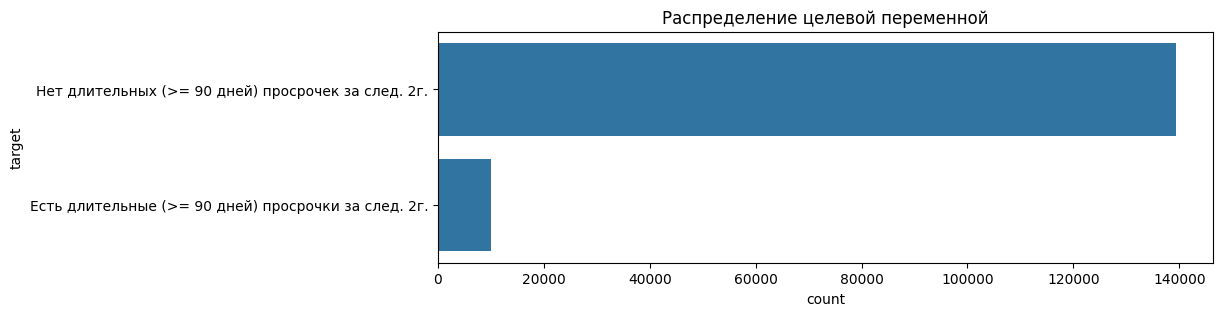

In [381]:
plt.figure(figsize=(10, 3))
sns.countplot(data, y="target")
plt.title("Распределение целевой переменной")
plt.yticks([0, 1], ["Нет длительных (>= 90 дней) просрочек за след. 2г.", "Есть длительные (>= 90 дней) просрочки за след. 2г."], rotation=0)
plt.show()

Соотношение классов

In [382]:
target_class_stats = (
    data["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_class_stats["percent"] = target_class_stats["count"] / target_class_stats["count"].sum() * 100

In [383]:
navigation["оценка соотношения классов"] = "target_class_stats"

In [384]:
target_class_stats

,target,count,percent
0,0,139382,93.3001
1,1,10009,6.6999


То есть base line 6.7%. Посчитаем ещё для верности доверительный интервал.

In [385]:
proportion_confint(
    count=data["target"].sum(),
    nobs=data.shape[0],
    alpha=0.05,
    method="wilson"
)

(0.06574195529796893, 0.06827767525493426)

**Вывод по блоку:**
1. Присутствует большой дисбаланс классов;
2. В качестве метрики качества accuracy будет неинформативной, стоит использовать ROC-AUC или PR-ROC.

# Анализ распределений признаков, выбросов и невозможных значений

Анализ числовых характеристик признаков

In [386]:
def make_features_values_analysis(data: pd.DataFrame) -> pd.DataFrame:    
    df_without_target = data.drop(columns="target")
    
    result = (
        df_without_target
        .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
        .T
    )[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

    result["gamma1"] = df_without_target.skew()
    result["gamma2"] = df_without_target.kurtosis()

    return result

In [387]:
navigation["функция для формирования числовых характеристик признаков"] =\
    "make_features_values_analysis(data: pd.DataFrame)"

In [388]:
features_values_analysis = make_features_values_analysis(data=data)

In [389]:
navigation["числовые характеристики признаков"] = "features_values_analysis"

In [390]:
features_values_analysis

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max,gamma1,gamma2
revolving_utilization,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0032,0.0301,6.0711,250.2637,0.1542,0.5565,0.9780,1.0000,1.0939,1.3689,"50,708.0000",97.4332,"14,485.6753"
age,"149,391.0000",0.0000,23.0000,24.0000,29.0000,33.0000,41.0000,52.3062,14.7260,52.0000,63.0000,72.0000,78.0000,87.0000,89.0000,109.0000,0.1923,-0.4940
num_30_59_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3939,3.8530,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,98.0000,24.4746,616.2456
debt_ratio,"149,391.0000",0.0000,0.0000,0.0000,0.0052,0.0350,0.1774,354.4367,"2,041.8435",0.3682,0.8753,"1,275.0000","2,455.5000","4,985.1000","6,191.0500","329,664.0000",94.9797,"13,681.5883"
monthly_income,"120,170.0000",0.0000,0.0000,0.0000,"1,300.0000","2,029.0000","3,400.0000","6,675.0983","14,389.5822","5,400.0000","8,250.0000","11,666.0000","14,594.1000","25,000.0000","35,000.0000","3,008,750.0000",114.0166,"19,493.9996"
num_open_credit_lines,"149,391.0000",0.0000,0.0000,0.0000,2.0000,3.0000,5.0000,8.4809,5.1365,8.0000,11.0000,15.0000,18.0000,24.0000,27.0000,58.0000,1.2218,3.1173
num_90_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2381,3.8262,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000,25.1074,637.8524
num_real_estate_loans,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0224,1.1302,1.0000,2.0000,2.0000,3.0000,4.0000,6.0000,54.0000,3.4847,60.5859
num_60_89_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2125,3.8105,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,98.0000,25.4244,649.0934
num_dependents,"145,563.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7599,1.1161,0.0000,1.0000,2.0000,3.0000,4.0000,5.0000,20.0000,1.5833,2.9843


Иллюстрация распределений признаков (для несемметричных будем использовать логарифмическое распределение)

In [391]:
discrete_features = [
    "num_30_59_days_late",
    "num_open_credit_lines",
    "num_90_days_late",
    "num_real_estate_loans",
    "num_60_89_days_late",
    "num_dependents"
]
continuous_features = [
    "revolving_utilization",
    "age",
    "debt_ratio",
    "monthly_income"
]

navigation["дискретные признаки"] = "discrete_features"
navigation["непрерывные признаки"] = "continuous_features"

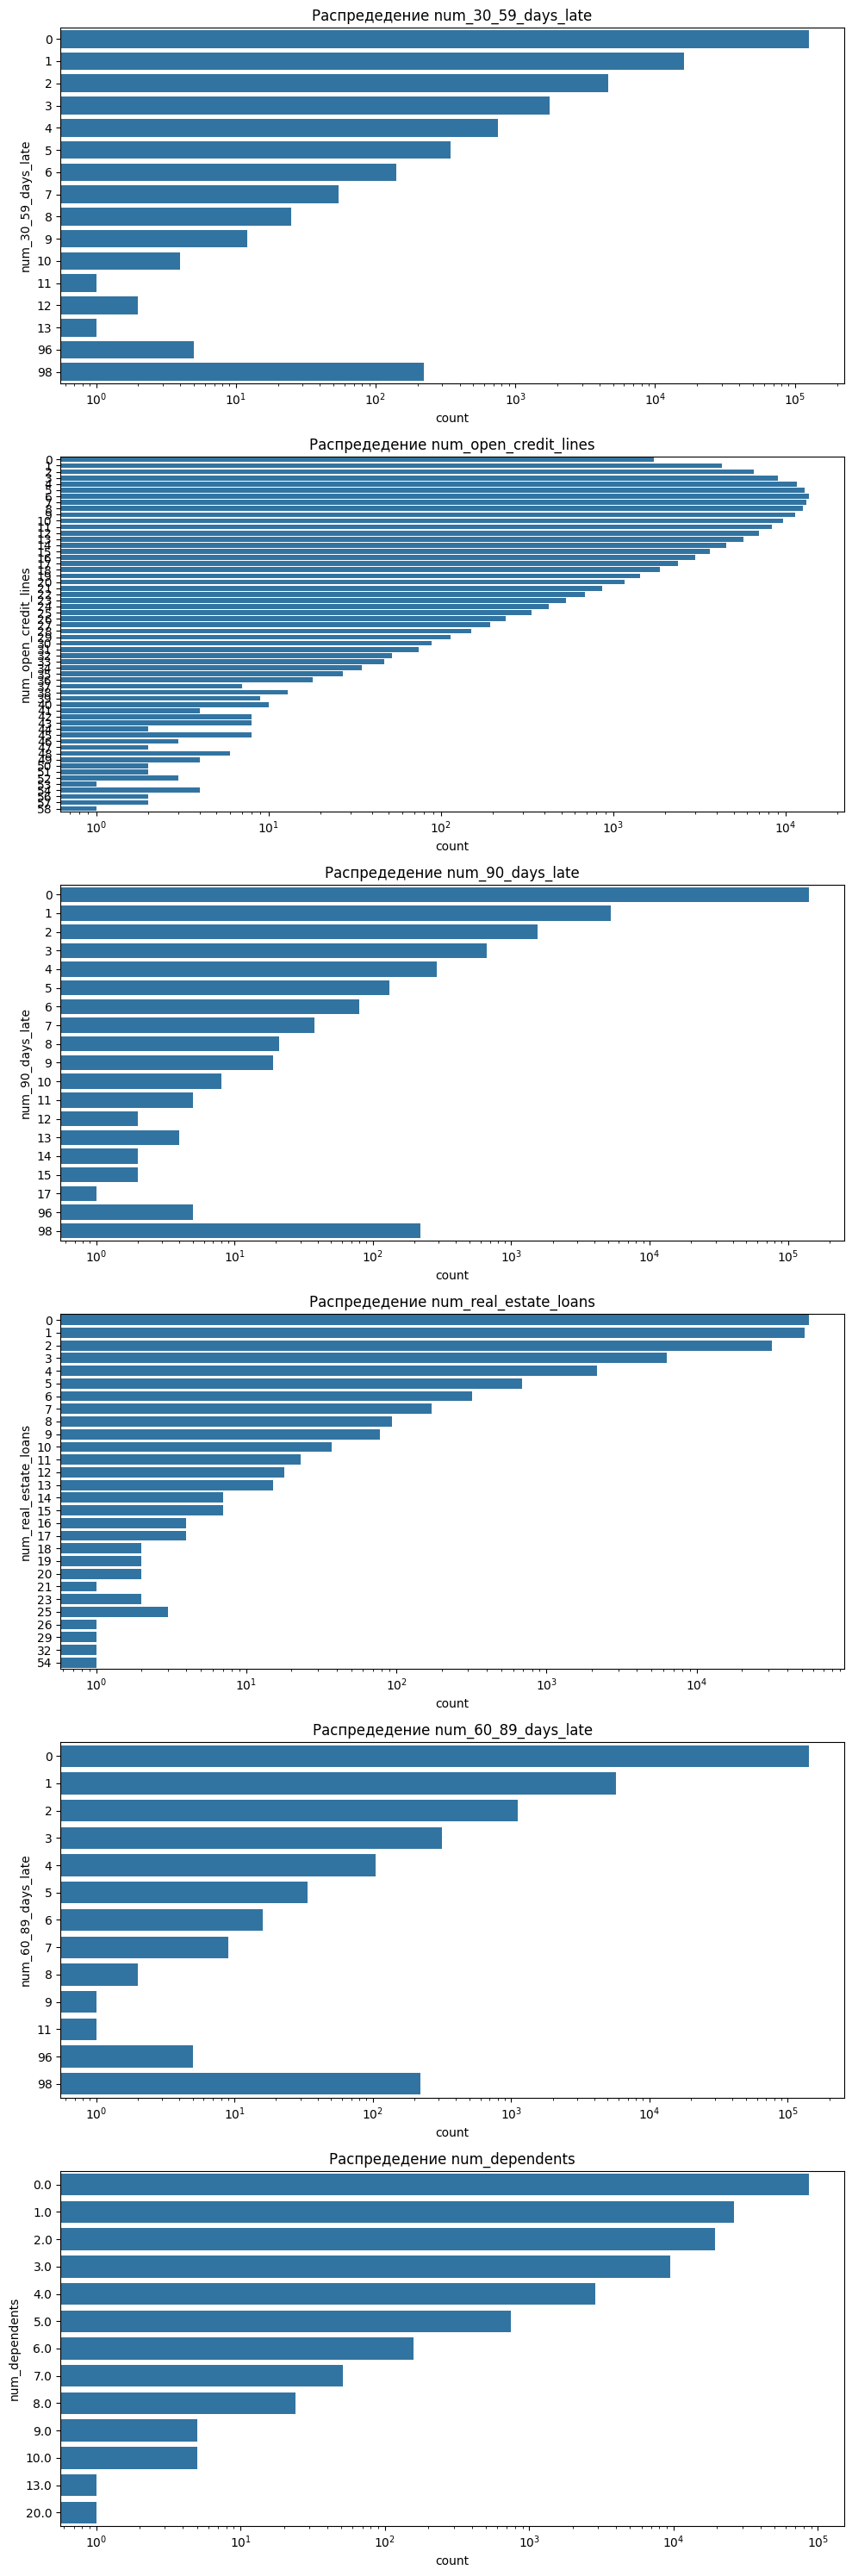

In [392]:
num_descrete_features = len(discrete_features)

plt.figure(figsize=(10, 30))
for i, column in enumerate(discrete_features):
    plt.subplot(num_descrete_features, 1, i + 1)
    sns.countplot(data=data, y=column)
    plt.xscale("log")
    plt.title(f"Распредедение {column}")

plt.tight_layout()
plt.show()

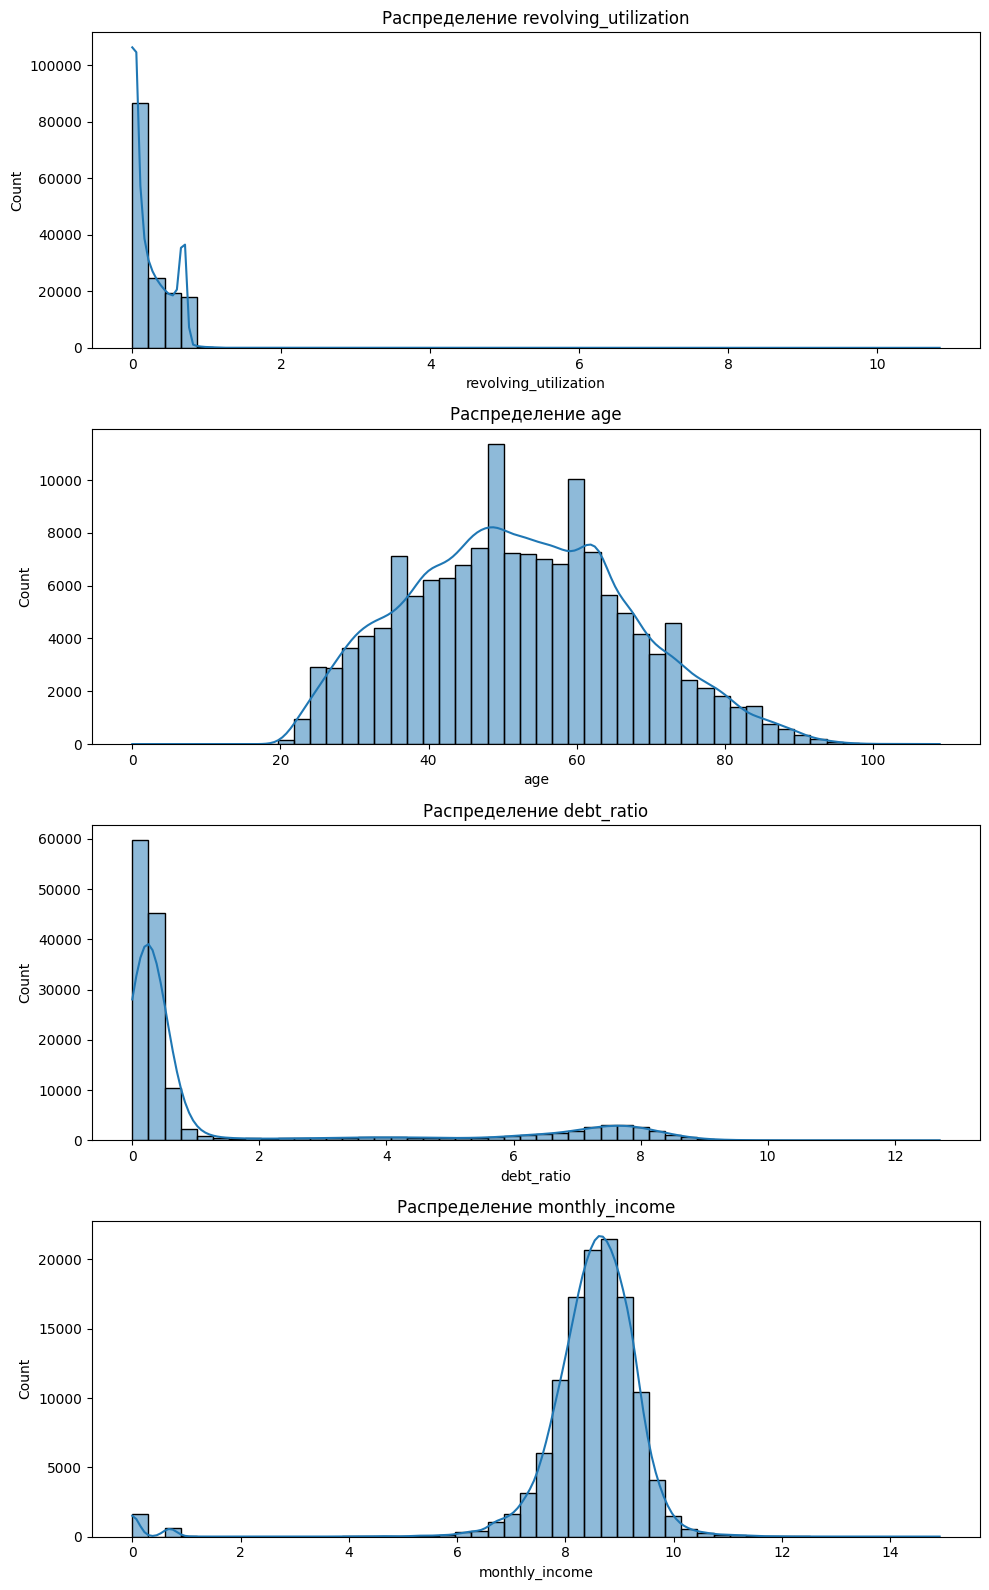

In [393]:
num_continuous_features = len(continuous_features)

plt.figure(figsize=(10, 16))
for i, column in enumerate(continuous_features):
    plt.subplot(num_continuous_features, 1, i + 1)
    if features_values_analysis.loc[column, "gamma1"] > 1:
        sns.histplot(np.log1p(data[column].dropna()), bins=50, kde=True)
    else:
        sns.histplot(data=data, x=column, bins=50, kde=True)
    plt.title(f"Распределение {column}")
    
plt.tight_layout()
plt.show()

**Вывод по блоку:**
1. Все признаки имеют ассиметричное распределение с тяжёлыми правыми хвостами;
2. Почти все признаки имеют серьёзные аномальные значения, сильно выбивающиеся из основного распределения;
3. В признаках `revolving_utilization`, `num_30_59_days_late`, `debt_ratio`, `num_open_credit_lines`, `num_90_days_late`, `num_real_estate_loans`, `num_60_89_days_late` аномальные значения, скорее всего являются ошибочными, требуется дополнительное рассмотрение;
4. Почти все выбросы из данных будут иметь негативное влияние на качество обучения, в том числе линейных моделей, которое приведёт к значительному снижению точности предсказания. Нужно будет продумать стратегии их обработки.

# Подробный анализ значений признаков (невозможные значения и выбросы)

## Переменная резюме

In [394]:
summary_features_values_analysis = pd.DataFrame({
    "feature": [],
    "связь с target": [],
    "наличие пропусков": [],
    "причины появления пропусков": [],
    "связь пропусков с target": [],
    "наличие экстремальных значений": [],
    "причины появления экстремальных значений": [],
    "связь экстремальных значений с target": [],
    "предполагаемая обработка признака": []
})

In [395]:
navigation["резюме по анализу значений признаков"] = "summary_features_values_analysis"
navigation["красивый вызов переменной резюме"] = 'summary_features_values_analysis.T.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})'

## `revolving_utilization`

**Обзор признака**

Признак `revolving utilization` показывает общий баланс по кредитным картам и кредитным линиям, кроме недвижимости и долгов в рассрочку.

Формула примерно следующая:

`суммарный долг по кредитным картам и личным кредитным линиям`
/
`суммарный лимит по этим кредитам и личным кредитным линиям`

Исходя из сути признака норма - это значения от `0` до `1`. Однако, как сейчас, так и в 2011 году была практика превышения кредитныйх лимитов, однако даже так, значения превышения можно представить до 5 раз, но не более. Все остальные значения нужно анализировать.

**Анализ значений признака**

Количественные характеристики признака

In [396]:
features_values_analysis.loc["revolving_utilization"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             0.0000
10%            0.0032
25%            0.0301
mean           6.0711
std          250.2637
50%            0.1542
75%            0.5565
90%            0.9780
95%            1.0000
99%            1.0939
99.5%          1.3689
max       50,708.0000
gamma1        97.4332
gamma2    14,485.6753
Name: revolving_utilization, dtype: float64

Беглый осмотр экстремальных значений

In [397]:
data.query(f"revolving_utilization > {features_values_analysis.loc["revolving_utilization", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
77572,0,"3,655.0000",39,0,0.1727,"9,230.0000",5,0,2,0,1.0000
46216,0,2.7166,36,1,970.0000,NaN,2,3,0,0,0.0000
70034,0,1.1631,61,0,44.0000,NaN,2,0,0,0,0.0000
104729,0,"3,448.0000",39,0,0.3812,"6,300.0000",6,0,2,0,0.0000
95671,1,1.3894,30,1,0.2519,"2,500.0000",6,4,0,1,1.0000
124647,0,112.0000,37,0,0.2325,"11,666.0000",2,0,1,0,4.0000
69027,0,1.4379,46,1,0.2385,"3,484.0000",3,1,1,0,3.0000
97320,1,1.2484,45,2,"3,374.0000",NaN,3,2,1,2,0.0000
79459,0,1.9978,59,0,0.3156,"11,200.0000",11,0,1,0,5.0000
46663,1,1.1199,25,1,0.1066,"1,800.0000",3,1,0,0,0.0000


In [398]:
data.query(f"revolving_utilization > {features_values_analysis.loc["revolving_utilization", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
137705,0,1.3738,69,0,598.0000,NaN,8,0,0,4,0.0000
44913,0,"3,081.0000",31,0,"3,465.0000",NaN,2,0,1,0,0.0000
40339,1,1.5272,46,1,0.0202,"4,500.0000",3,3,0,4,2.0000
123676,0,"3,484.0000",47,0,0.1509,"7,222.0000",4,0,1,0,0.0000
105759,1,1.4651,37,0,0.2199,"2,300.0000",5,3,0,2,2.0000
68137,0,"7,096.0000",46,0,0.2842,"11,324.0000",6,0,1,0,1.0000
145988,1,1.5725,31,2,518.0000,NaN,8,3,0,1,0.0000
89530,0,5.3477,31,0,0.4704,"8,453.0000",5,0,1,0,0.0000
75206,0,"1,029.0000",71,0,30.0000,NaN,4,0,0,0,0.0000
108630,0,2.0931,50,4,0.3040,"13,576.0000",14,0,2,1,3.0000


Можно заметить, что зачастую огромные значения `revolving_utilization` часто сопровождается весьма небольшим значением `debt_ratio`. Это означает, что человек в десятки и тысячи раз превышает свой кредитный лимит, который установил ему банк, но при этом он тратит на обслужтивание кредитов часто даже не половину своего дохода.

Таким образом, это наталкивает на мысль, что значения, например, выше 2, скорее всего говорят о том, что лимит был установлен не верно, что и привело к аномальным значениям - ошибкам.

Посмотрим на распределение `debt_ratio` у экстремальных значений `revolving_utilization`. Правда при этом экстремальные значения `debt_ratio`, cвязанные с отсутствующим или низким `monthly_income` исключим.

In [399]:
num_samples_with_extreme_values_in_debt_ratio_and_monthly_income = (
    data
    .query(f"debt_ratio > {features_values_analysis.loc["debt_ratio", "99%"]}")
    .query(f"(monthly_income < {features_values_analysis.loc["monthly_income", "1%"]}) or (not monthly_income.notna())")    
).shape[0]
num_samples_with_extreme_values_in_debt_ratio_and_monthly_income

1410

In [400]:
(
    data
    .query(f"revolving_utilization > 2.0")
    .query(f"(monthly_income.notna()) or (monthly_income > {features_values_analysis.loc["monthly_income", "1%"]})")
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
).loc[
    ["debt_ratio", "monthly_income"],
    ["count", "min", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "max"]
]

,count,min,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,max
debt_ratio,278.0000,0.0008,0.0027,0.0205,0.0598,0.1515,20.6225,213.3877,0.2834,0.4700,0.8107,1.1522,158.8968,"2,597.0000"
monthly_income,278.0000,0.0000,31.0300,"1,624.6500","2,189.8000","4,000.0000","7,883.5252","6,419.8110","6,358.0000","10,000.0000","14,697.2000","18,617.5000","36,696.3200","44,472.0000"


Видно, что подавляющее большинство экстремальных значений `revolving_utilization` связано с `debt_ratio` не превышающим 1, а 75% вообще не превышающим даже 0.5. Таким образом, гипотеза о том, что экстремальные значения `revolving_utilization` (> 2.0) скорее связано с ошибками (неверный кридитный лимит (знаменатель, который и приводит к некорректным значениям дроби)).

Проверим ещё связь аномальных значений с целевой переменной.

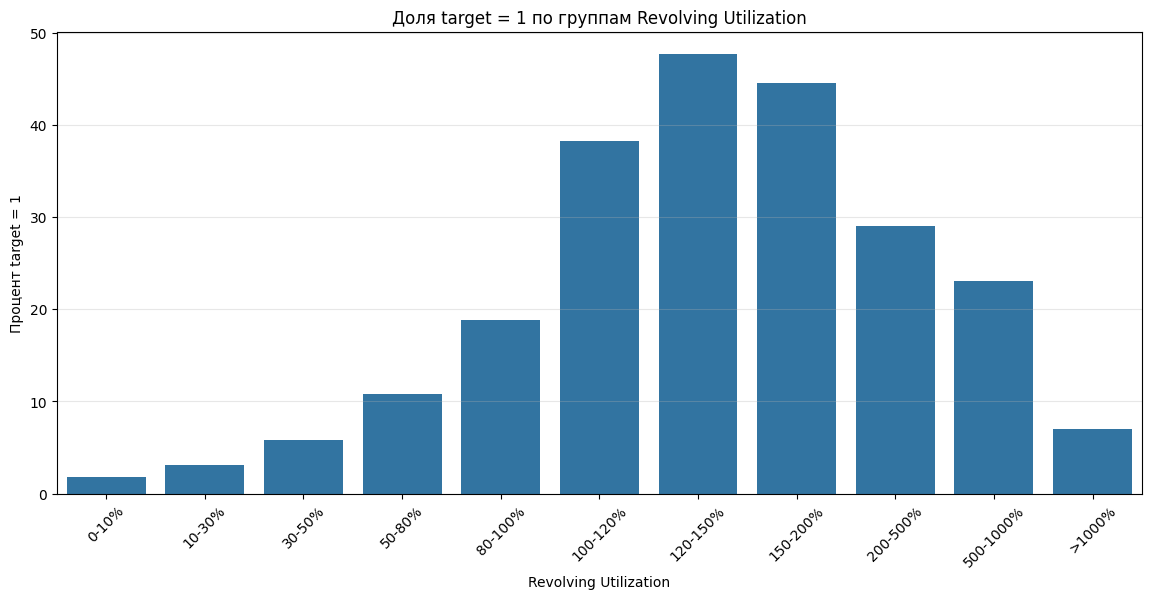

In [401]:
bins = [0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 5.0, 10.0, np.inf]
labels = ["0-10%", "10-30%", "30-50%", "50-80%", "80-100%", "100-120%", "120-150%", "150-200%", "200-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["rev_util_bin"] = pd.cut(
    temp["revolving_utilization"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

rev_util_summary = (
    temp
    .groupby("rev_util_bin", observed=True)
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)

rev_util_summary["target_1_pct"] = rev_util_summary["target_1_rate"] * 100
rev_util_summary["CI_bin"] = rev_util_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
rev_util_summary["target_1_pct_all"] = data["target"].mean() * 100
rev_util_summary["lift"] = rev_util_summary["target_1_pct"] - (data["target"].mean() * 100)
rev_util_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=rev_util_summary,
    x="rev_util_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам Revolving Utilization")
plt.xlabel("Revolving Utilization")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [402]:
rev_util_summary[
    [
        "rev_util_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,rev_util_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-10%,64095,1.8192,6.6999,-4.8807,0.0172 - 0.0193,0.0656 - 0.0681
1,10-30%,28478,3.1428,6.6999,-3.5571,0.0295 - 0.0335,0.0656 - 0.0681
2,30-50%,15830,5.8497,6.6999,-0.8502,0.0549 - 0.0623,0.0656 - 0.0681
3,50-80%,16155,10.7768,6.6999,4.0770,0.1031 - 0.1126,0.0656 - 0.0681
4,80-100%,21512,18.7988,6.6999,12.0989,0.1828 - 0.1933,0.0656 - 0.0681
5,100-120%,2283,38.1954,6.6999,31.4955,0.3622 - 0.4021,0.0656 - 0.0681
6,120-150%,438,47.7169,6.6999,41.0170,0.4308 - 0.5239,0.0656 - 0.0681
7,150-200%,229,44.5415,6.6999,37.8416,0.3825 - 0.5102,0.0656 - 0.0681
8,200-500%,117,29.0598,6.6999,22.3600,0.2160 - 0.3785,0.0656 - 0.0681
9,500-1000%,13,23.0769,6.6999,16.3771,0.0818 - 0.5026,0.0656 - 0.0681


Наблюдается положительная связь диапазонов значений `revolving_utilization` [0.8, 5.0], так как lift у этих бинов весьма велик и значим. Левый хвост, вероятно, имеет небольшую обратную связь. Правый хвост, скорее всего, никакой особой связи не имеет, так как бин 500-1000% слишком мал, а >1000% имеет lift при небольшом числе samplов всего 0.35.

Проверим ещё возможный случай, когда `revolving_utilization` > 0 и при этом `num_open_credit_lines` и `num_real_estate_loans` равны 0.

In [403]:
temp = data.query("(revolving_utilization > 0) and (num_open_credit_lines == 0) and (num_real_estate_loans == 0)")

temp.shape[0]

1712

In [404]:
temp.sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
103590,0,1.0000,33,0,0.0000,"2,500.0000",0,0,0,0,0.0000
6687,0,1.0000,75,0,0.0000,NaN,0,0,0,0,2.0000
128183,0,1.0000,48,0,65.0000,NaN,0,0,0,0,0.0000
27796,0,1.0000,27,0,0.0000,"2,000.0000",0,0,0,0,0.0000
64340,0,1.0000,41,0,0.0038,"4,784.0000",0,1,0,0,2.0000
818,0,1.0000,48,0,0.1652,"6,421.0000",0,1,0,0,2.0000
103238,1,1.0000,37,0,0.0000,"4,151.0000",0,0,0,0,2.0000
49435,1,1.0000,50,1,0.0000,"1,588.0000",0,1,0,0,0.0000
110801,1,1.0000,34,0,0.0000,"2,494.0000",0,0,0,0,2.0000
91219,0,1.0000,66,0,0.0000,NaN,0,0,0,0,1.0000


Посмотрим на распределение признаков у подобных представителей.

In [405]:
(
    data
    .drop(columns="target")
    .query("(revolving_utilization > 0) and (num_open_credit_lines == 0) and (num_real_estate_loans == 0)")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,"1,712.0000",0.8828,1.0000,1.0000,1.0000,1.0000,1.0000,1.0056,0.0987,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,3.8623
age,"1,712.0000",21.0000,21.0000,21.0000,23.0000,24.0000,29.0000,42.4083,15.3603,40.0000,53.0000,64.0000,70.4500,82.0000,86.0000,92.0000
num_30_59_days_late,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12.8405,32.9501,0.0000,0.0000,98.0000,98.0000,98.0000,98.0000,98.0000
debt_ratio,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.6894,67.0082,0.0000,0.0528,43.0000,97.9000,302.0100,393.3350,"1,205.0000"
monthly_income,"1,147.0000",0.0000,0.0000,0.0000,600.0000,986.0000,"1,800.0000","3,470.9076","3,233.3773","2,783.0000","4,064.0000","6,500.0000","8,733.1000","16,000.0000","20,211.9300","44,514.0000"
num_open_credit_lines,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_90_days_late,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,13.2734,32.7983,0.0000,1.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_real_estate_loans,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_60_89_days_late,"1,712.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12.8143,32.9598,0.0000,0.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_dependents,"1,587.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6068,1.0482,0.0000,1.0000,2.0000,3.0000,4.0000,5.0000,6.0000


Посмотрим на особенного представителя

In [406]:
data.query("(revolving_utilization > 0) and ((revolving_utilization - 1.0 > 10e-4) or (revolving_utilization - 1.0 < -10e-4)) and (num_open_credit_lines == 0) and (num_real_estate_loans == 0)")

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
16176,0,3.1262,23,0,0.0209,"2,200.0000",0,1,0,0,0.0000
33769,0,1.8130,23,0,41.0000,NaN,0,2,0,0,0.0000
37187,1,0.8828,48,0,153.0000,NaN,0,1,0,0,0.0000
63271,1,3.8623,54,0,0.0262,"4,500.0000",0,2,0,2,0.0000
65725,1,0.8988,51,0,0.1806,"4,788.0000",0,4,0,0,2.0000
68621,0,1.8368,53,0,114.0000,NaN,0,2,0,0,0.0000
73126,0,2.0040,28,0,59.0000,NaN,0,1,0,0,0.0000
79504,0,1.6611,26,0,0.0175,858.0000,0,1,0,0,0.0000
105463,0,1.6846,24,0,109.0000,NaN,0,1,0,0,NaN
142363,0,1.8323,56,0,38.0000,0.0000,0,1,0,0,0.0000


Эти данные я интерпретирую так:
1. значение 1.0 в `revolving_utilization` означает отсутствие долгов и лимитов. При условии, конечно, что `num_open_credit_lines` и `num_real_estate_loans` равны 0;
2. комбинация `revolving_utilization` > 0 и != 1.0 + нулевое количество кридитных линий и кредитов под залог жилья, скорее всего, говорит об ошибке в данных. Думаю, что все такие представители - это представители с ошибками, так как такое возможно только, если какой-то из признаков не обновлён или есть какие-то скрытые кредиты. В любом случае такие данные в рамках объяснений публичного необъясними никаким образом, кроме ошибок.

Думаю, что такие данные стоит удалить.

In [407]:
bad_mask = (
    (data["revolving_utilization"] > 0)
    & ((data["revolving_utilization"] - 1.0).abs() > 10e-4)
    & (data["num_open_credit_lines"] == 0)
    & (data["num_real_estate_loans"] == 0)
)

data = data[~bad_mask].copy()

**Вывод по значениям признака:**
1. Количество экстремальных, нереалистичных значений, у данного признака не велико, что наталкивает на мысль об ошибках;
2. Экстремальные значения > 1000% часто сопровождаются невысоким `debt_ratio`, что наталкивает на мысли о том, что лимиты были с ошибками, что и привело к аномалиям;
3. Огромные значения как правило не коррелируют с `target`, только умеренные, так что с ошибками можно поступать по разному;
4. Комбинация `revolving_utilization` = 1.0, `num_open_credit_lines` = 0, `num_real_estate_loans` = 0 говорит о том, что у человека долги и лимиты равны 0;
5. Комбинация `revolving_utilization` > 0 и != 1.0, `num_open_credit_lines` = 0, `num_real_estate_loans` = 0 - это, скорее всего, ошибки, которые я удалил.

Таким образом, в признаке нормальные значения, скорее всего, располагаются до 10, всё, что выше - это ошибки.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг об аномальности значения с порогом > 10;
2. выполнить логарифмирование признака для выравнивания масштаба значений признака;
3. выполнить бинаризацию признака.

In [408]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "revolving_utilization",
    "Значительная нелинейная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Экстремальные значения скорее всего появляются по следующим причинам:\n1) Необновлённое значение кредитного лемита, которое и приводит к экстремальному значению дроби;\n2) Неверное значение кредитного лемита, которое приводит к экстремальному значению в дроби.\nНа это наталкивает некоторая связь экстремального значения `revolving_utilization` с небольшим значением `debt_ratio`, что должно вызывать противоречие. Кроме того, значения больше 5 уже сами по себе не являются адекватными по любым меркам.",
    "Сначения от 0.8 до 5.0 имеет значимую положительную связь с target. Значения выше значимой связи не имеют: либо слишком маленький lift, либо слишком мало представителей.",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг об аномальности значения с порогом > 10;\n2. выполнить логарифмирование признака для выравнивания масштаба значений признака;\n3. выполнить бинаризацию признака."
]

## `age`

**Обзор признака**

Признак `age` означает возраст заёмщика.

Исходя из смысла признака, стоит ожидать значения от 18 до 110.

**Анализ значений признака**

Количественные характеристики признака

In [409]:
features_values_analysis.loc["age"]

count    149,391.0000
min            0.0000
0.5%          23.0000
1%            24.0000
5%            29.0000
10%           33.0000
25%           41.0000
mean          52.3062
std           14.7260
50%           52.0000
75%           63.0000
90%           72.0000
95%           78.0000
99%           87.0000
99.5%         89.0000
max          109.0000
gamma1         0.1923
gamma2        -0.4940
Name: age, dtype: float64

Беглый осмотр данных с аномальными значениями в признаке

In [410]:
data.query(f"age > {features_values_analysis.loc["age", "90%"]}").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
11861,0,0.0055,78,0,676.0000,NaN,7,0,1,0,0.0000
5018,0,0.2881,78,0,0.3613,"5,581.0000",15,0,1,0,0.0000
84079,0,0.0666,77,0,32.0000,NaN,3,0,0,0,0.0000
85549,0,0.0286,81,0,0.1195,"4,400.0000",9,0,1,0,0.0000
46049,0,0.1540,79,0,0.2391,"5,833.0000",17,0,1,0,1.0000
73958,0,0.3938,80,1,973.0000,NaN,11,0,0,1,0.0000
955,0,0.6309,73,0,0.0474,"4,577.0000",3,0,0,0,0.0000
15215,0,0.0438,75,0,"1,392.0000",NaN,5,0,1,0,0.0000
128079,0,0.7045,75,0,"2,505.0000",NaN,6,0,2,0,0.0000
94883,0,0.0000,79,0,0.0000,NaN,5,0,0,0,NaN


В целом я бы не сказал, что тут есть что-то особенное или заслуживающее внимания.

Посмотрим на корреляцию с целевым признаком

In [411]:
features_values_analysis.loc["age"]

count    149,391.0000
min            0.0000
0.5%          23.0000
1%            24.0000
5%            29.0000
10%           33.0000
25%           41.0000
mean          52.3062
std           14.7260
50%           52.0000
75%           63.0000
90%           72.0000
95%           78.0000
99%           87.0000
99.5%         89.0000
max          109.0000
gamma1         0.1923
gamma2        -0.4940
Name: age, dtype: float64

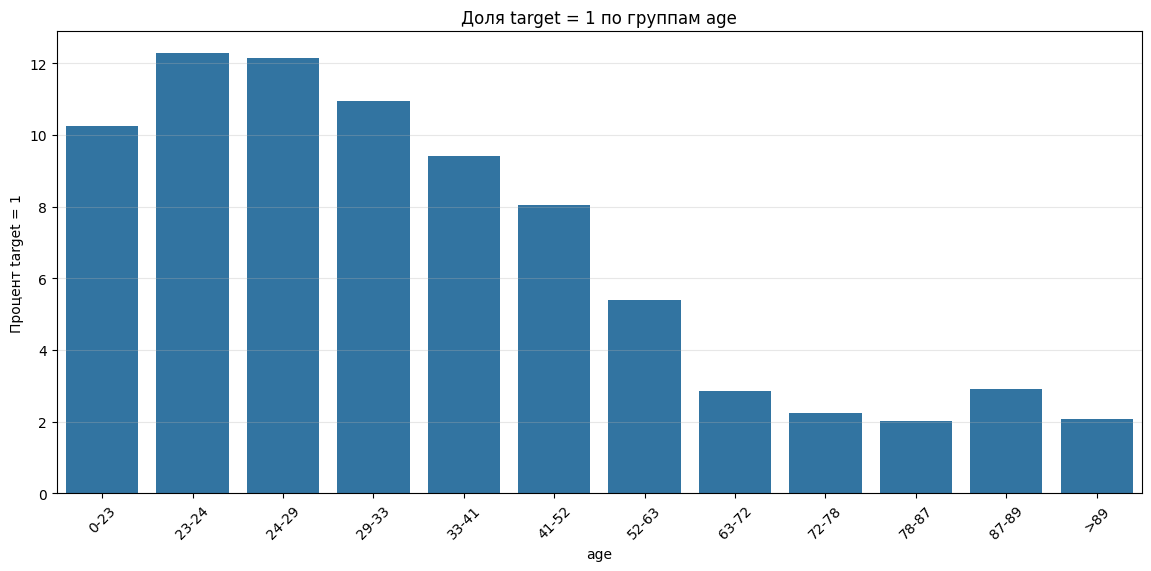

In [412]:
bins = [0, 23, 24, 29, 33, 41, 52, 63, 72, 78, 87, 89, np.inf]
labels = ["0-23", "23-24", "24-29", "29-33", "33-41", "41-52", "52-63", "63-72", "72-78", "78-87", "87-89", ">89"]

temp = data.copy(deep=True)
temp["age_bin"] = pd.cut(
    x=temp["age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

age_summary = (
    temp
    .groupby(by="age_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
age_summary["target_1_pct"] = age_summary["target_1_rate"] * 100
age_summary["CI_bin"] = age_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
age_summary["target_1_pct_all"] = data["target"].mean() * 100
age_summary["lift"] = age_summary["target_1_pct"] - (data["target"].mean() * 100)
age_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=age_summary,
    x="age_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам age")
plt.xlabel("age")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [413]:
age_summary[
    [
        "age_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,age_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-23,1121,10.2587,6.6983,3.5604,0.0862 - 0.1217,0.0656 - 0.0681
1,23-24,782,12.2762,6.6983,5.5779,0.1016 - 0.1476,0.0656 - 0.0681
2,24-29,6702,12.1605,6.6983,5.4622,0.1140 - 0.1296,0.0656 - 0.0681
3,29-33,8246,10.9508,6.6983,4.2525,0.1029 - 0.1164,0.0656 - 0.0681
4,33-41,21098,9.4132,6.6983,2.7149,0.0903 - 0.0981,0.0656 - 0.0681
5,41-52,39100,8.0486,6.6983,1.3503,0.0778 - 0.0832,0.0656 - 0.0681
6,52-63,38283,5.4019,6.6983,-1.2964,0.0518 - 0.0563,0.0656 - 0.0681
7,63-72,19837,2.8533,6.6983,-3.8451,0.0263 - 0.0309,0.0656 - 0.0681
8,72-78,7511,2.2500,6.6983,-4.4483,0.0194 - 0.0261,0.0656 - 0.0681
9,78-87,5448,2.0191,6.6983,-4.6792,0.0168 - 0.0243,0.0656 - 0.0681


Присутствует небольшая обратная связь.

**Вывод по значениям признака:**
1. В признаке есть выбросы;
2. Не похоже, что в признаке есть ошибки;
4. Присутствует небольшая обратная связь с `target`.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. выполнить логарифмирование признака, для выравнивания масштаба.

In [414]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "age",
    "Присутствует некоторая обратная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Ошибки отсутвуют, просто большие значения",
    "Небольшая обратная связь",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. выполнить логарифмирование признака, для выравнивания масштаба."
]

## `num_30_59_days_late` / `num_60_89_days_late` / `num_90_days_late`

**Обзор признака**

Признак `num_30_59_days_late` (`60_89`/`90`) показывает, были ли у человека просрочки от `30` (`60` или `90`) до `59` (`89` или `неограничено`) дней.

Исходя из сути признака норма - это значения не сильно большие, думаю уж точно не больше 10, так как трудно представить, что кто-то будет выдавать много кредитов тому, кто и так уже имеет просрочки. Скорее всего, несколько просрочек может быть у человека, если ему выдали новый кредит на погашение старого или у него было несколько кредитов одновременно и он стал неплатёжеспособным, что и привело к нескольким просрочкам сразу.

**Анализ значений признака**

Количественные характеристики признаков

In [415]:
features_values_analysis.loc[["num_30_59_days_late", "num_60_89_days_late", "num_90_days_late"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max,gamma1,gamma2
num_30_59_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3939,3.8530,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,98.0000,24.4746,616.2456
num_60_89_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2125,3.8105,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,98.0000,25.4244,649.0934
num_90_days_late,"149,391.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2381,3.8262,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000,25.1074,637.8524


Беглый осмотр данных с аномальными значениями данных признаков

In [416]:
data.query(f"num_30_59_days_late > {features_values_analysis.loc["num_30_59_days_late", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
118469,1,0.0000,35,8,0.7111,"16,000.0000",14,0,7,0,4.0000
73065,1,1.0000,29,98,0.0000,NaN,0,98,0,98,0.0000
23248,0,1.0228,39,5,"1,123.0000",NaN,5,1,0,1,2.0000
102240,1,1.0000,36,98,0.0079,"3,275.0000",0,98,0,98,2.0000
88437,1,0.6838,49,5,2.2810,"2,924.0000",9,0,3,2,0.0000
53603,1,1.0000,21,98,0.0000,"1,300.0000",0,98,0,98,0.0000
99781,0,0.9918,55,6,0.6522,"7,487.0000",18,0,3,1,0.0000
54931,0,0.5475,52,6,2.3905,"1,469.0000",24,0,1,1,4.0000
6089,0,0.0000,51,6,0.2222,"8,833.0000",6,1,1,0,0.0000
138142,0,0.1092,37,6,0.4285,"3,000.0000",14,1,0,2,2.0000


In [417]:
data.query(f"num_30_59_days_late > {features_values_analysis.loc["num_30_59_days_late", "99.5%"]}").sort_values(by="num_30_59_days_late").tail(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
11362,1,1.0000,27,98,0.0000,NaN,0,98,0,98,0.0000
11161,1,1.0000,26,98,0.0000,NaN,0,98,0,98,NaN
10245,1,1.0000,28,98,0.0000,"1,700.0000",0,98,0,98,0.0000
10201,0,1.0000,23,98,0.0000,1.0000,0,98,0,98,0.0000
9685,0,1.0000,28,98,0.0000,"1,400.0000",0,98,0,98,0.0000
9648,1,1.0000,53,98,0.0000,"1,900.0000",0,98,0,98,0.0000
9278,0,1.0000,24,98,0.0000,"1,488.0000",0,98,0,98,0.0000
144586,1,1.0000,60,98,0.0000,"1,375.0000",0,98,0,98,0.0000
144230,1,1.0000,31,98,0.0000,"2,200.0000",0,98,0,98,3.0000
143715,0,1.0000,33,98,0.0000,"2,534.0000",0,98,0,98,0.0000


Видно, что встречаются как весьма обычные значения, так и очень странные значения `96` и `98`. Причём эти значения стоят сразу в трёх признаках. Нужно проверить не какой-то ли это системный код.

Количество строк с num_30_59_days_late, num_60_89_days_late, num_90_days_late не равными одновременно 98

In [418]:
eq_values_for_features_days_late_98 =\
    data.query("num_30_59_days_late == 98 | num_60_89_days_late == 98 | num_90_days_late == 98")

num_not_all_days_late_eq_98 =\
    eq_values_for_features_days_late_98.shape[0]\
    -\
    eq_values_for_features_days_late_98.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late == 98").shape[0]

In [419]:
num_not_all_days_late_eq_98

0

Количество строк с `num_30_59_days_late`, `num_60_89_days_late`, `num_90_days_late` не равными одновременно 96

In [420]:
eq_values_for_features_days_late_96 =\
    data.query("num_30_59_days_late == 96 | num_60_89_days_late == 96 | num_90_days_late == 96")

num_not_all_days_late_eq_96 =\
    eq_values_for_features_days_late_96.shape[0]\
    -\
    eq_values_for_features_days_late_96.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late == 96").shape[0]

In [421]:
num_not_all_days_late_eq_96

0

Так как всегда значения `98` и `96` стоят во всех 3 признаках одновременно, то теория о том, что данные значения являются системными кодами выглядит весьма правдоподобной.

Проверим ещё распределение других признаков значениях количества просрочек 96 и 98.

In [422]:
(
    data
    .drop(columns="target")
    .query(f"(num_90_days_late == 96) or (num_90_days_late == 98)")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,225.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
age,225.0000,21.0000,21.0000,21.0000,21.0000,22.0000,25.0000,36.0711,13.1792,31.0000,46.0000,56.0000,60.0000,67.5200,71.5200,79.0000
num_30_59_days_late,225.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9556,0.2955,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
debt_ratio,225.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.7643,28.3092,0.0000,0.0053,13.8000,43.4000,114.2400,233.5200,255.0000
monthly_income,145.0000,0.0000,0.0000,0.0000,307.6000,704.4000,"1,375.0000","2,610.0414","2,749.0575","2,180.0000","3,200.0000","4,060.0000","6,856.6000","8,498.5600","14,536.7600","28,733.0000"
num_open_credit_lines,225.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0089,0.0941,0.0000,0.0000,0.0000,0.0000,0.0000,0.8800,1.0000
num_90_days_late,225.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9556,0.2955,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_real_estate_loans,225.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_60_89_days_late,225.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9556,0.2955,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_dependents,208.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4231,0.8758,0.0000,0.0000,2.0000,2.0000,3.9300,4.0000,5.0000


Теперь ещё заметны следующие странности - `revolving_utilization` равен 1.0 + почти нет представителей с открытыми кредитными линиями + вообще нет ипотек или кредитных линий под залог недвижимости.

Кроме того, есть странность с `debt_ratio` - непонятно почему он тогда не нулевой, если представителей с кредитными линиями почти нет - нужно тоже это проверить.

Тогда посмотрим на представителей с `debt_ratio` > 0 и `num_open_credit_lines` > 0.

In [423]:
data.query(f"((num_90_days_late == 98) or (num_90_days_late == 96)) and (debt_ratio > 0)").sample(59)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
147128,1,1.0000,37,98,0.0076,"3,166.0000",0,98,0,98,0.0000
33258,1,1.0000,33,98,120.0000,NaN,0,98,0,98,0.0000
96003,0,1.0000,60,98,0.0435,"1,700.0000",0,98,0,98,0.0000
147774,1,1.0000,68,98,255.0000,NaN,0,98,0,98,0.0000
79018,1,1.0000,35,98,10.0000,NaN,0,98,0,98,0.0000
128197,1,1.0000,54,98,0.0130,"2,000.0000",0,98,0,98,0.0000
68564,1,1.0000,43,98,0.0017,"2,328.0000",0,98,0,98,2.0000
38540,0,1.0000,65,98,0.1255,525.0000,0,98,0,98,0.0000
23915,1,1.0000,65,98,0.0122,"1,800.0000",0,98,0,98,0.0000
84076,1,1.0000,25,98,35.0000,NaN,0,98,0,98,0.0000


In [424]:
data.query(f"((num_90_days_late == 98) or (num_90_days_late == 96)) and (num_open_credit_lines > 0)").sample(2)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
121885,1,1.0000,44,98,0.0000,"6,283.0000",1,98,0,98,2.0000
17980,0,1.0000,35,98,0.0000,"1,700.0000",1,98,0,98,1.0000


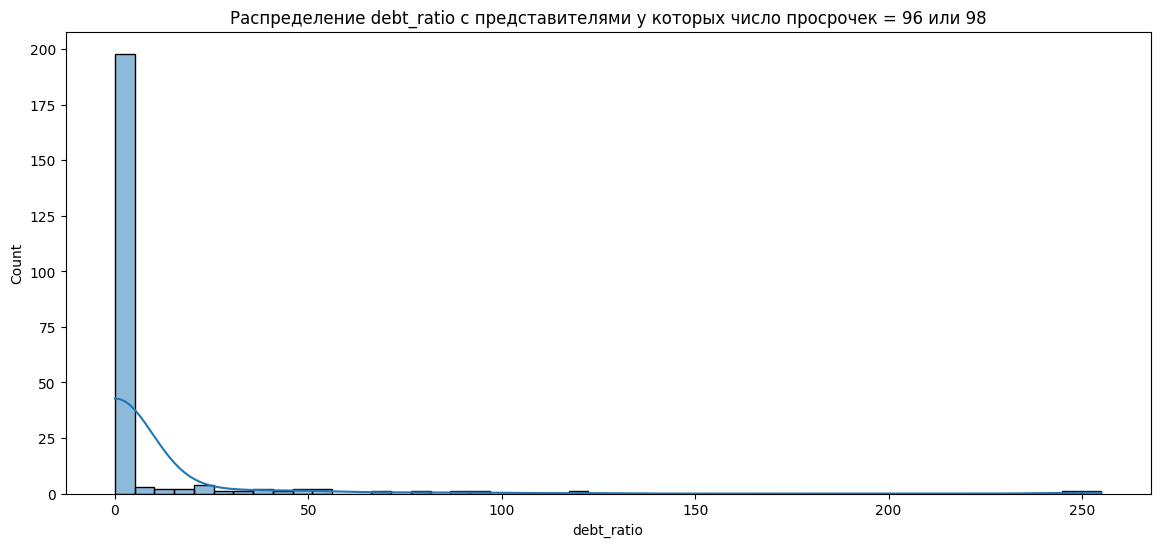

In [425]:
temp = data.query("(num_90_days_late == 96) or (num_90_days_late == 98)")

plt.figure(figsize=(14, 6))
sns.histplot(data=temp, x="debt_ratio", bins=50, kde=True)
plt.title("Распределение debt_ratio с представителями у которых число просрочек = 96 или 98")
plt.show()

Посмотрим ещё на различие распределений с разным `target`.

In [426]:
(
    data
    .query(f"((num_90_days_late == 96) or (num_90_days_late == 98)) and (target == 0)")
    .drop(columns="target")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,89.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
age,89.0000,21.0000,21.0000,21.0000,21.0000,22.0000,24.0000,33.3483,12.1507,28.0000,43.0000,51.2000,54.4000,65.8400,68.9200,72.0000
num_30_59_days_late,89.0000,96.0000,96.8800,97.7600,98.0000,98.0000,98.0000,97.9775,0.2120,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
debt_ratio,89.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.7475,12.5826,0.0000,0.0000,0.0250,7.2969,69.9600,73.4800,77.0000
monthly_income,62.0000,0.0000,0.0000,0.0000,1.0000,310.0000,"1,410.0000","2,840.0968","3,834.7423","2,000.0000","3,206.0000","4,500.0000","7,485.9000","16,705.6300","22,719.3150","28,733.0000"
num_open_credit_lines,89.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0112,0.1060,0.0000,0.0000,0.0000,0.0000,0.1200,0.5600,1.0000
num_90_days_late,89.0000,96.0000,96.8800,97.7600,98.0000,98.0000,98.0000,97.9775,0.2120,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_real_estate_loans,89.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_60_89_days_late,89.0000,96.0000,96.8800,97.7600,98.0000,98.0000,98.0000,97.9775,0.2120,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_dependents,83.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3855,0.8949,0.0000,0.0000,1.8000,2.0000,4.1800,4.5900,5.0000


In [427]:
(
    data
    .query(f"((num_90_days_late == 96) or (num_90_days_late == 98)) and (target == 1)")
    .drop(columns="target")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,136.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
age,136.0000,21.0000,21.0000,21.0000,22.0000,24.0000,26.0000,37.8529,13.5600,33.0000,48.2500,58.0000,62.0000,67.3000,71.5750,79.0000
num_30_59_days_late,136.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9412,0.3392,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
debt_ratio,136.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9.3929,34.7699,0.0000,0.0097,21.5000,50.2500,203.8500,250.9500,255.0000
monthly_income,83.0000,0.0000,138.5800,277.1600,681.6000,826.2000,"1,362.5000","2,438.1928","1,504.0636","2,200.0000","3,155.0000","3,786.4000","5,810.0000","7,561.2000","7,700.6000","7,840.0000"
num_open_credit_lines,136.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0074,0.0857,0.0000,0.0000,0.0000,0.0000,0.0000,0.3250,1.0000
num_90_days_late,136.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9412,0.3392,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_real_estate_loans,136.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_60_89_days_late,136.0000,96.0000,96.0000,96.0000,98.0000,98.0000,98.0000,97.9412,0.3392,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000,98.0000
num_dependents,125.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4480,0.8656,0.0000,1.0000,2.0000,2.0000,3.0000,3.3800,4.0000


Данные можно интерпретировать так:
1. `revolving_utilization` = 1 + `num_open_credit_lines` = 0 / 1 - это означает то, что данные представители ничего не должны, а `revolving_utilization` = 1, скорее всего, свидетельствует о том, что долг = 0 и лимит = 0.
2. значения `debt_ratio` больше напоминают шум, адекватных значений почти нет. Значения либо слишком маленькие, меньше 0.1 (при уровне дохода это около 100-200 долларов или евро, что вряд ли тянет на плату за жильё, либо на плату алиментов), либо слишком большие, но большие значения всегда идут вместе с отсутствующим ежемесячным доходом, что наталкивает на мысли об ошибках.
3. `num_open_credit_lines` = 0 и `num_real_estate_loans` = 0 наталкивает на мысль, что человек никакие кредиты в банке не оформлял и вообще с кредитами дел не имеет.

Вообще данные напоминают какие-то незавершённые заявки.

Теперь посмотрим на связь этих значений с `target`.

In [428]:
bins = [0, 1, 2, 4, 6, 10, 17, 18, 96, 98]
labels = ["0-1", "1-2", "2-4", "4-6", "6-10", "10-17", "ничего", "96", "98"]

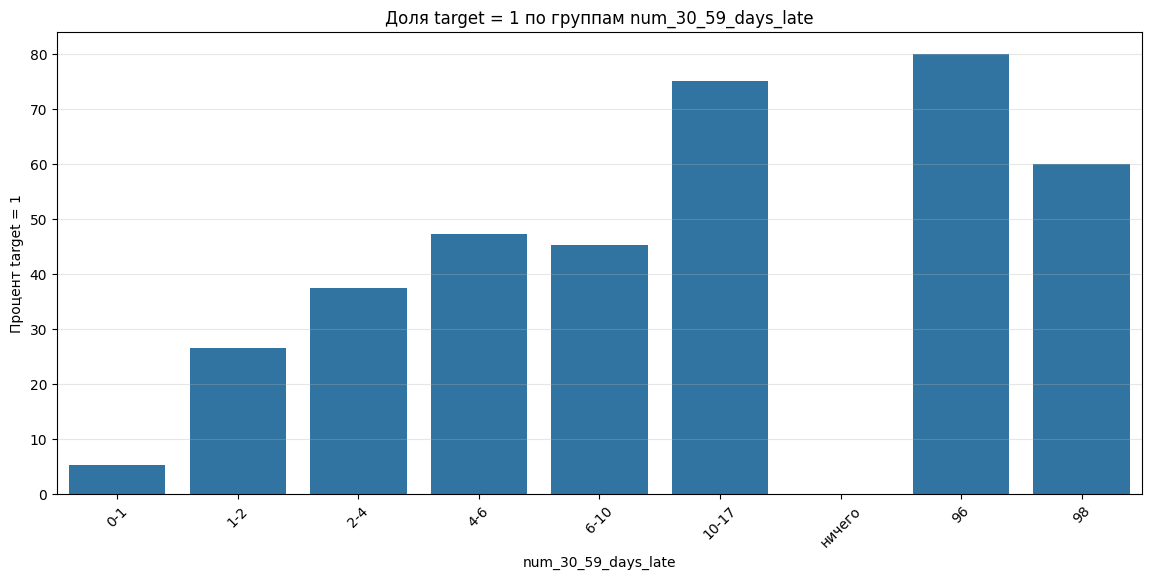

In [429]:
temp = data.copy(deep=True)
temp["num_30_59_days_late_bin"] = pd.cut(
    x=temp["num_30_59_days_late"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_30_59_days_late_summary = (
    temp.groupby("num_30_59_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)

num_30_59_days_late_summary["target_1_pct"] = num_30_59_days_late_summary["target_1_rate"] * 100
num_30_59_days_late_summary["CI_bin"] = num_30_59_days_late_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_30_59_days_late_summary["target_1_pct_all"] = data["target"].mean() * 100
num_30_59_days_late_summary["lift"] = num_30_59_days_late_summary["target_1_pct"] - (data["target"].mean() * 100)
num_30_59_days_late_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"


plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_30_59_days_late_summary,
    x="num_30_59_days_late_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_30_59_days_late")
plt.xlabel("num_30_59_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [430]:
num_30_59_days_late_summary[
    [
        "num_30_59_days_late_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_30_59_days_late_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-1,141476,5.2595,6.6983,-1.4388,0.0514 - 0.0538,0.0656 - 0.0681
1,1-2,4598,26.5115,6.6983,19.8132,0.2526 - 0.2781,0.0656 - 0.0681
2,2-4,2501,37.4250,6.6983,30.7267,0.3555 - 0.3934,0.0656 - 0.0681
3,4-6,482,47.3029,6.6983,40.6046,0.4288 - 0.5176,0.0656 - 0.0681
4,6-10,95,45.2632,6.6983,38.5648,0.3563 - 0.5526,0.0656 - 0.0681
5,10-17,4,75.0000,6.6983,68.3017,0.3006 - 0.9544,0.0656 - 0.0681
6,96,5,80.0000,6.6983,73.3017,0.3755 - 0.9638,0.0656 - 0.0681
7,98,220,60.0000,6.6983,53.3017,0.5341 - 0.6625,0.0656 - 0.0681


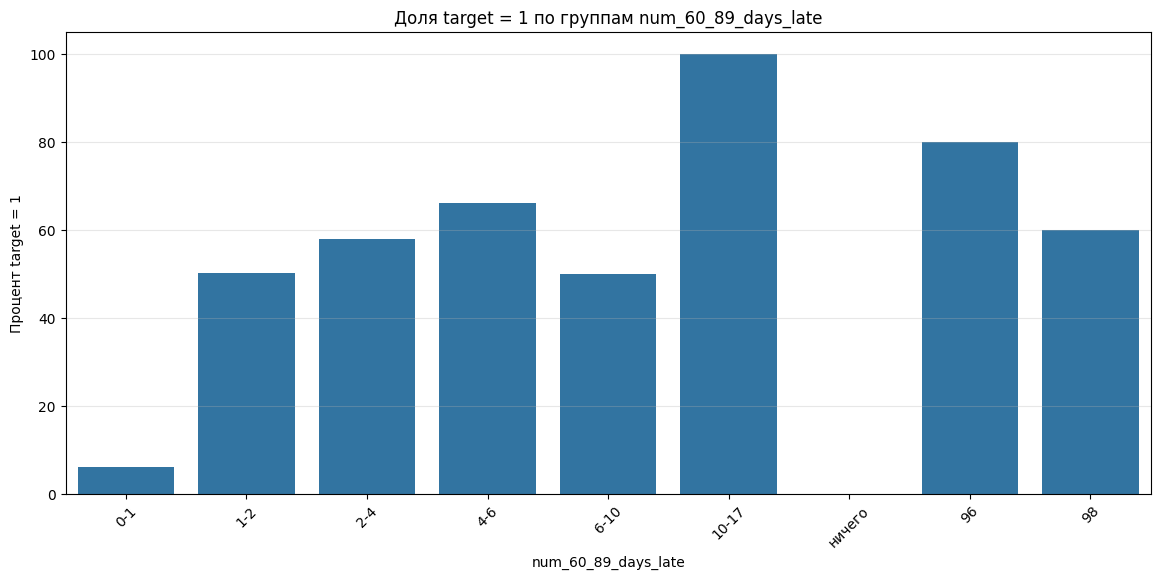

In [431]:
temp = data.copy(deep=True)
temp["num_60_89_days_late_bin"] = pd.cut(
    x=temp["num_60_89_days_late"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_60_89_days_late_summary = (
    temp.groupby("num_60_89_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_60_89_days_late_summary["target_1_pct"] = num_60_89_days_late_summary["target_1_rate"] * 100
num_60_89_days_late_summary["CI_bin"] = num_60_89_days_late_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_60_89_days_late_summary["target_1_pct_all"] = data["target"].mean() * 100
num_60_89_days_late_summary["lift"] = num_60_89_days_late_summary["target_1_pct"] - (data["target"].mean() * 100)
num_60_89_days_late_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_60_89_days_late_summary,
    x="num_60_89_days_late_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_60_89_days_late")
plt.xlabel("num_60_89_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [432]:
num_60_89_days_late_summary[
    [
        "num_60_89_days_late_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_60_89_days_late_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-1,147553,6.1164,6.6983,-0.5819,0.0600 - 0.0624,0.0656 - 0.0681
1,1-2,1117,50.1343,6.6983,43.4360,0.4721 - 0.5306,0.0656 - 0.0681
2,2-4,423,57.9196,6.6983,51.2213,0.5316 - 0.6253,0.0656 - 0.0681
3,4-6,50,66.0000,6.6983,59.3017,0.5215 - 0.7756,0.0656 - 0.0681
4,6-10,12,50.0000,6.6983,43.3017,0.2538 - 0.7462,0.0656 - 0.0681
5,10-17,1,100.0000,6.6983,93.3017,0.2065 - 1.0000,0.0656 - 0.0681
6,96,5,80.0000,6.6983,73.3017,0.3755 - 0.9638,0.0656 - 0.0681
7,98,220,60.0000,6.6983,53.3017,0.5341 - 0.6625,0.0656 - 0.0681


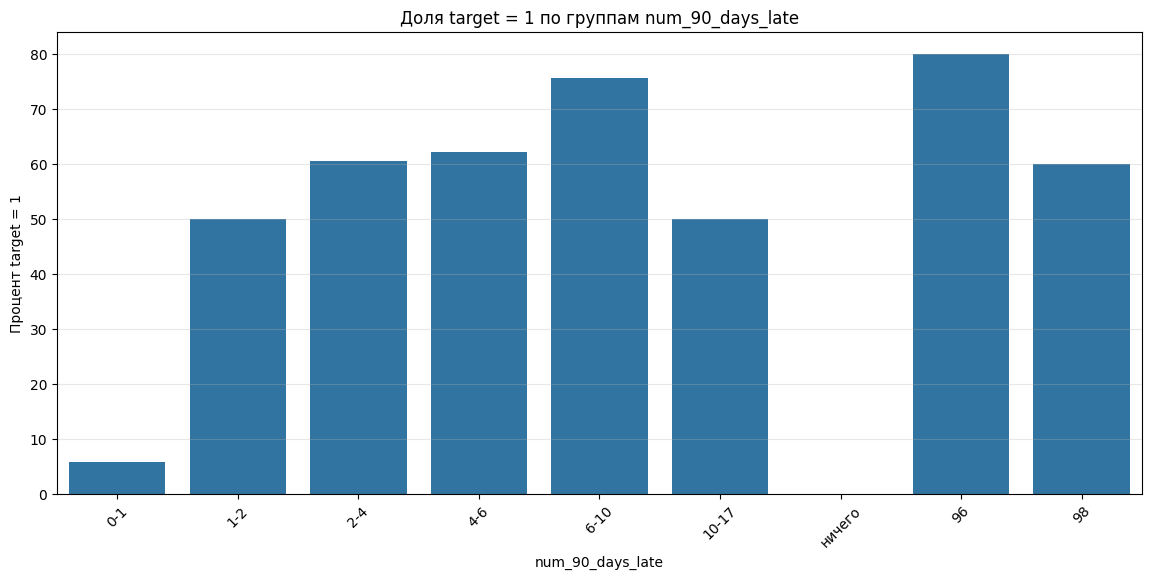

In [433]:
temp = data.copy(deep=True)
temp["num_90_days_late_bin"] = pd.cut(
    x=temp["num_90_days_late"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_90_days_late_summary = (
    temp.groupby("num_90_days_late_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_90_days_late_summary["target_1_pct"] = num_90_days_late_summary["target_1_rate"] * 100
num_90_days_late_summary["CI_bin"] = num_90_days_late_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_90_days_late_summary["target_1_pct_all"] = data["target"].mean() * 100
num_90_days_late_summary["lift"] = num_90_days_late_summary["target_1_pct"] - (data["target"].mean() * 100)
num_90_days_late_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_90_days_late_summary,
    x="num_90_days_late_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_90_days_late")
plt.xlabel("num_90_days_late")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [434]:
num_90_days_late_summary[
    [
        "num_90_days_late_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_90_days_late_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-1,146334,5.6802,6.6983,-1.0182,0.0556 - 0.0580,0.0656 - 0.0681
1,1-2,1552,49.9356,6.6983,43.2373,0.4745 - 0.5242,0.0656 - 0.0681
2,2-4,957,60.5016,6.6983,53.8033,0.5737 - 0.6355,0.0656 - 0.0681
3,4-6,211,62.0853,6.6983,55.3870,0.5538 - 0.6836,0.0656 - 0.0681
4,6-10,86,75.5814,6.6983,68.8831,0.6554 - 0.8344,0.0656 - 0.0681
5,10-17,16,50.0000,6.6983,43.3017,0.2800 - 0.7200,0.0656 - 0.0681
6,96,5,80.0000,6.6983,73.3017,0.3755 - 0.9638,0.0656 - 0.0681
7,98,220,60.0000,6.6983,53.3017,0.5341 - 0.6625,0.0656 - 0.0681


1. Связь между положительным числом просрочек и target есть, она положительна и значима;
2. Экстремальные значения - 96 и 98 - это явно какие-то системные коды +, учитывая, что target_1_rate у них очень высокий, можно предположить, что это вообще какие-то мошенники;
3. Экстремальные значения явно лежат до 17 или около того, всё, что уже равняется 96 и 98 - это не число просрочек, а системный код.

**Вывод по значениям признаков:**

1. Экстремальные значения (возможные), в данной выборке <= 17;
2. Значения 96 и 98, учитывая рассмотренные обстоятельства, скорее всего являются системными кодами и, возможно, сигнализируют о мошенниках;
3. Присутствует значимая положительная связь между числом просрочек и targetом.

**Предполагаемая обработка признаков:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. добавить флаг о равенстве признаков 96 или 98;
2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;
3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков;
4. выполнить бинаризацию признаков.

In [435]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "num_30_59_days_late / num_60_89_days_late / num_90_days_late",
    "Значительная нелинейная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Учитывая то, что при экстремальных значениях 96 и 98 все три столбца содержат это значение + `revolving_utilization` = 0 + `num_open_credit_lines` = 0 (почти всегда) и `num_real_estate_loans` = 0 + странный `debt_ratio` можно сделать вывод, что это системные коды, которые, возможно, сигнализируют о мошенниках.",
    "Имеют положительную значимую связь с target",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. добавить флаг о равенстве признаков 96 или 98;\n2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения;\n3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков;\n4. выполнить бинаризацию признаков."
]

## `debt_ratio`

**Обзор признака**

Признак `debt_ratio` означает отношение выплат по долгам (сюда входят ещё алименты и расходы на проживание) к ежемесячному валовому доходу.

Формула примерно такая:

`Сумма ежемесячных выплат по долгам` / `ежемесячный валовый доход`.

**Анализ значений признака**

Количественные характеристики признака

In [436]:
features_values_analysis.loc["debt_ratio"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             0.0052
10%            0.0350
25%            0.1774
mean         354.4367
std        2,041.8435
50%            0.3682
75%            0.8753
90%        1,275.0000
95%        2,455.5000
99%        4,985.1000
99.5%      6,191.0500
max      329,664.0000
gamma1        94.9797
gamma2    13,681.5883
Name: debt_ratio, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [437]:
data.query("(debt_ratio > 1.0) and (debt_ratio < 3.0)").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
65392,0,0.2609,57,0,1.0551,"3,158.0000",14,0,1,0,0.0000
80729,1,0.2987,35,0,1.3167,"6,500.0000",10,0,4,0,2.0000
105510,0,0.3302,61,0,1.2621,"6,000.0000",22,0,3,0,0.0000
71935,0,0.2243,27,0,2.6412,300.0000,7,0,0,0,0.0000
47379,0,0.2972,46,0,1.1128,"4,485.0000",16,0,2,0,2.0000
94550,0,0.2716,54,0,2.2805,"1,500.0000",16,0,2,0,0.0000
63453,0,0.0000,42,0,1.2339,"4,000.0000",8,0,4,0,1.0000
103930,1,0.1734,29,0,1.1599,"1,700.0000",16,0,0,0,0.0000
44885,0,0.4884,58,1,1.1191,"5,650.0000",20,0,1,1,0.0000
89319,0,0.7256,41,0,1.6818,"4,000.0000",9,0,3,0,3.0000


In [438]:
data.query(f"debt_ratio > 3.0").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
31828,0,0.0000,50,0,"2,020.0000",NaN,11,0,2,0,0.0000
129039,0,0.1971,44,0,"3,616.0000",NaN,12,0,1,0,0.0000
62380,0,0.0039,89,0,5.0000,NaN,5,0,0,0,NaN
61321,0,0.2303,62,0,"1,366.0000",NaN,3,0,1,0,0.0000
110285,0,0.9927,32,0,802.0000,NaN,3,0,0,0,0.0000
27037,0,0.0004,55,0,"1,273.0000",NaN,8,0,0,0,0.0000
77694,0,0.2050,62,0,165.0000,NaN,4,0,0,0,0.0000
79665,0,0.0000,47,0,"6,875.0000",NaN,8,0,3,0,0.0000
6654,0,1.0000,40,0,65.0000,NaN,1,0,0,0,0.0000
73672,0,0.9589,57,0,648.0000,NaN,6,0,0,0,0.0000


Глядя на данные, можно сделать предположение, что нормальные данные лежат недалеко от `1`, а больше `3-4` это уже неадекватные значения, связанные с какими-то странными значениями в `monthly_income`. Проверим это.

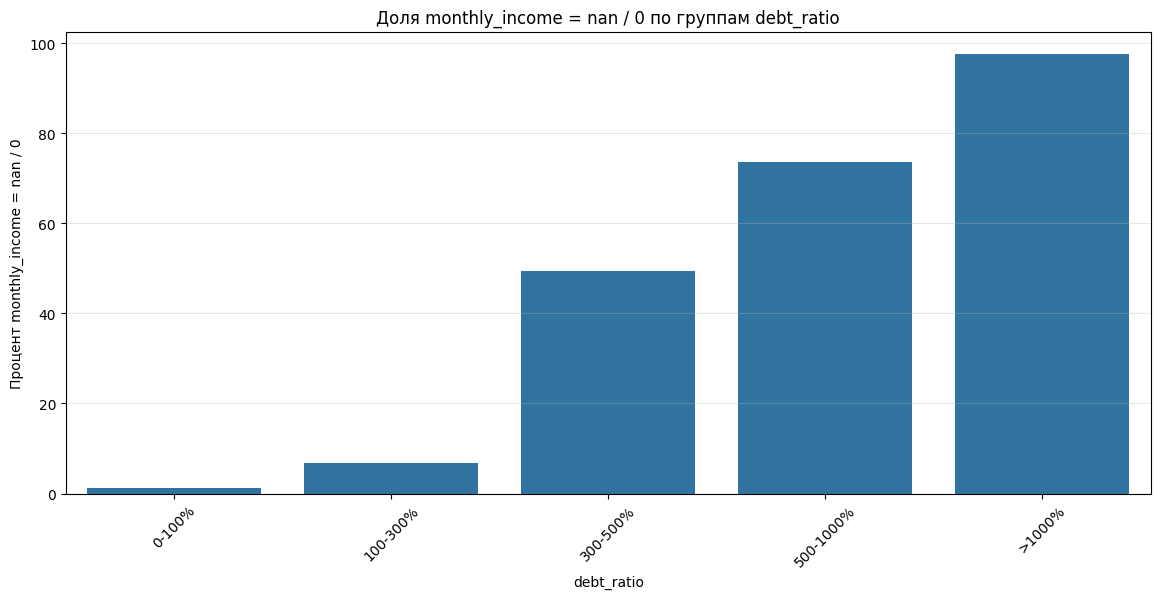

In [439]:
bins = [0, 1, 3, 5, 10, np.inf]
labels = ["0-100%", "100-300%", "300-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["debt_ratio_bin"] = pd.cut(
    x=temp["debt_ratio"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)
temp["monthly_income_zero_or_nan"] = (temp["monthly_income"].fillna(0.0) == 0).astype(int)

debt_ratio_zero_and_nan_mon_inc_summary = (
    temp
    .groupby("debt_ratio_bin")
    .agg(
        count=("monthly_income", "size"),
        monthly_income_zero_or_nan_count=("monthly_income_zero_or_nan", "sum"),
        monthly_income_zero_or_nan_rate=("monthly_income_zero_or_nan", "mean")
    )
    .reset_index()
)
debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_pct"] =\
    debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_rate"] * 100
debt_ratio_zero_and_nan_mon_inc_summary["CI_bin"] = debt_ratio_zero_and_nan_mon_inc_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["monthly_income_zero_or_nan_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_pct_all"] = temp["monthly_income_zero_or_nan"].mean() * 100
debt_ratio_zero_and_nan_mon_inc_summary["lift"] =\
    debt_ratio_zero_and_nan_mon_inc_summary["monthly_income_zero_or_nan_pct"] - (temp["monthly_income_zero_or_nan"].mean() * 100)
debt_ratio_zero_and_nan_mon_inc_summary["CI_all"] =\
    "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=temp["monthly_income_zero_or_nan"].sum(),
        nobs=temp.shape[0],
        alpha=0.05,
        method="wilson"
    ))

plt.figure(figsize=(14, 6))

sns.barplot(
    data=debt_ratio_zero_and_nan_mon_inc_summary,
    x="debt_ratio_bin",
    y="monthly_income_zero_or_nan_pct"
)

plt.title("Доля monthly_income = nan / 0 по группам debt_ratio")
plt.xlabel("debt_ratio")
plt.ylabel("Процент monthly_income = nan / 0")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [440]:
debt_ratio_zero_and_nan_mon_inc_summary[
    [
        "debt_ratio_bin",
        "count",
        "monthly_income_zero_or_nan_pct",
        "monthly_income_zero_or_nan_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,debt_ratio_bin,count,monthly_income_zero_or_nan_pct,monthly_income_zero_or_nan_pct_all,lift,CI_bin,CI_all
0,0-100%,114257,1.2419,20.6392,-19.3972,0.0118 - 0.0131,0.2043 - 0.2085
1,100-300%,4852,6.6777,20.6392,-13.9615,0.0601 - 0.0741,0.2043 - 0.2085
2,300-500%,637,49.4505,20.6392,28.8114,0.4558 - 0.5332,0.2043 - 0.2085
3,500-1000%,768,73.5677,20.6392,52.9285,0.7034 - 0.7656,0.2043 - 0.2085
4,>1000%,28867,97.7171,20.6392,77.0779,0.9754 - 0.9788,0.2043 - 0.2085


Процент экстремальных значений `debt_ratio` среди `monthly_income` == nan или 0.

In [441]:
temp = data.copy(deep=True)
temp = temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)")

temp.query("debt_ratio > 3.0").shape[0] / temp.shape[0] * 100

94.34659920210177

Процент экстремальных значений `debt_ratio` среди `monthly_income` != nan или 0.

In [442]:
temp = data.copy(deep=True)
temp = temp.query("(monthly_income.notna()) and (monthly_income > 0)")

temp.query("debt_ratio > 10.0").shape[0] / temp.shape[0] * 100

0.5558835934204978

Результаты можно интерпретировать так:
1. Большинство экстремальных значений связаны с 0 или отсутствующим `monthly_income`. Вероятно, такие значения нельзя интерпретировать как обычное отношение долговых платежей к доходу;
2. Некоторые экстремальные значения связаны с низкими доходами и высокими расходами. Тут нельзя никак утверждать об ошибках, так как человек вполне может жить на уже заработанные деньги (например, наследство), а работать за небольшие деньги, что не является запретным или ошибочным.

Теперь проверим связь экстремальных значений с `target`.

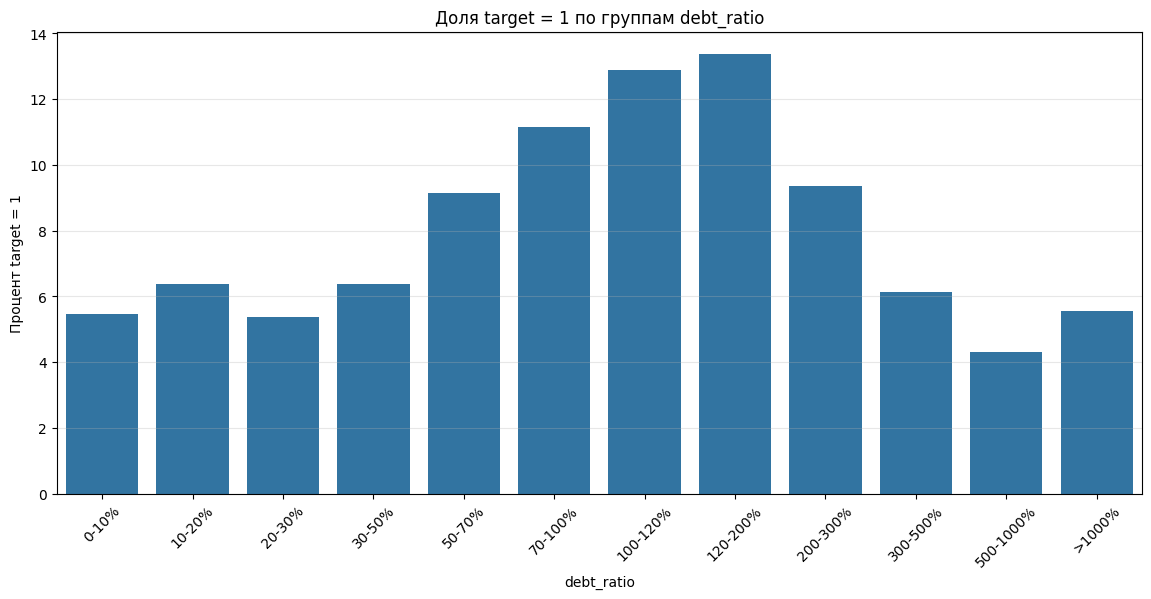

In [443]:
bins = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.2, 2.0, 3.0, 5.0, 10.0, np.inf]
labels = ["0-10%", "10-20%", "20-30%", "30-50%", "50-70%", "70-100%", "100-120%", "120-200%", "200-300%", "300-500%", "500-1000%", ">1000%"]

temp = data.copy(deep=True)
temp["debt_ratio_bin"] = pd.cut(
    x=temp["debt_ratio"],
    bins=bins,
    labels=labels,
    right=True
)

debt_ratio_summary = (
    temp
    .groupby("debt_ratio_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
debt_ratio_summary["target_1_pct"] = debt_ratio_summary["target_1_rate"] * 100
debt_ratio_summary["CI_bin"] = debt_ratio_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
debt_ratio_summary["target_1_pct_all"] = data["target"].mean() * 100
debt_ratio_summary["lift"] = debt_ratio_summary["target_1_pct"] - (data["target"].mean() * 100)
debt_ratio_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=debt_ratio_summary,
    x="debt_ratio_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам debt_ratio")
plt.xlabel("debt_ratio")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [444]:
debt_ratio_summary[
    [
        "debt_ratio_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,debt_ratio_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-10%,20404,5.4548,6.6983,-1.2435,0.0515 - 0.0577,0.0656 - 0.0681
1,10-20%,17768,6.3597,6.6983,-0.3386,0.0601 - 0.0673,0.0656 - 0.0681
2,20-30%,20272,5.3719,6.6983,-1.3264,0.0507 - 0.0569,0.0656 - 0.0681
3,30-50%,31147,6.3602,6.6983,-0.3381,0.0609 - 0.0664,0.0656 - 0.0681
4,50-70%,13811,9.1304,6.6983,2.4321,0.0866 - 0.0962,0.0656 - 0.0681
5,70-100%,7340,11.1580,6.6983,4.4597,0.1046 - 0.1190,0.0656 - 0.0681
6,100-120%,1701,12.8748,6.6983,6.1765,0.1137 - 0.1455,0.0656 - 0.0681
7,120-200%,2391,13.3835,6.6983,6.6852,0.1208 - 0.1481,0.0656 - 0.0681
8,200-300%,760,9.3421,6.6983,2.6438,0.0747 - 0.1162,0.0656 - 0.0681
9,300-500%,637,6.1224,6.6983,-0.5759,0.0451 - 0.0826,0.0656 - 0.0681


Подумаем как объяснить увиденное:
1. С умеренным `debt_ratio` до 1.0 всё понятно, тут проблем нет;

Высокий же `debt_ratio` может иметь следующие случаи:
1. Низкий или отсутствующий доход и наличие кредитов:
    1. Если у людей нет просрочек, то это предположительно люди, которые попали в трудные жизненные обстоятельства и лишились дохода, но при этом сохранили деньги, чтобы выплачивать долги;
    2. Если у людей есть просрочки, то это предположительно люди, которые попали в трудные жизненные обстоятельства и лишились дохода, но при этом не сохранили деньги, чтобы выплачивать долги;
2. Низкий или отсутствующих доход и отсутствие кредитов. Это должны быть люди, которые не имеют дохода, но должны платить по за квартиру или алименты, при этом банку они ничего не должны;
3. Люди с умеренным или высоким доходом и наличием кредитов. Это должны быть люди, которые потеряли часть своего доход и поэтому их `debt_ratio` вырос, но при этом он не должен быть сильно высоким, например, не выше 10;
4. Люди с умеренным или высоким доходм и отсутствием кредитов. Это уже очень странные представители. Можно лишь предположить, что такие люди живут не посредставм или или в текущий месяц сильно тратятся, например, сняли номер на месяц в 4 сезонах;
5. Все отсальные случаи - это уже какие-то особые трудные случаи или ошибки.

Таким образом, +- все сценарии объясняются, однако при отсутствующем доходе `debt_ratio` явно ведёт себя по странному. Совсем уж огромные значения можно даже принять за абсолютные значения долгов, а не отношение к доходам.

Теперь посмотрим сколько процентов расписанные мной случаи покрывают.

In [445]:
temp = data.query("debt_ratio > 1.0")

first_point = temp.query(f"((not monthly_income.notna()) or (monthly_income < {features_values_analysis.loc["monthly_income", "5%"]})) and ((num_open_credit_lines > 0) or (num_real_estate_loans > 0))")
first_1_point = first_point.query("num_30_59_days_late == num_60_89_days_late == num_90_days_late == 0")
first_2_point = first_point.query("(num_30_59_days_late > 0) or (num_60_89_days_late > 0) or (num_90_days_late > 0)")

second_point = temp.query(f"((not monthly_income.notna()) or (monthly_income < {features_values_analysis.loc["monthly_income", "5%"]})) and (num_open_credit_lines == num_real_estate_loans == 0)")

third_point = temp.query(f"(monthly_income > {features_values_analysis.loc["monthly_income", "5%"]}) and ((num_open_credit_lines > 0) or (num_real_estate_loans > 0)) and (debt_ratio <= 10.0)")

forth_point = temp.query(f"(monthly_income > {features_values_analysis.loc["monthly_income", "5%"]}) and (num_open_credit_lines == num_real_estate_loans == 0)")

first_1_point_pct = first_1_point.shape[0] / temp.shape[0] * 100
first_2_point_pct = first_2_point.shape[0] / temp.shape[0] * 100
second_point_pct = second_point.shape[0] / temp.shape[0] * 100
third_point_pct = third_point.shape[0] / temp.shape[0] * 100
forth_point_pct = forth_point.shape[0] / temp.shape[0] * 100

points_explanation_percent =\
    pd.concat([first_1_point, first_2_point, second_point, third_point, forth_point], ignore_index=True).drop_duplicates().shape[0] / temp.shape[0] * 100

print(f"first 1 point explanation percent = {first_1_point_pct:.4f}")
print(f"first 2 point explanation percent = {first_2_point_pct:.4f}")
print(f"second point explanation percent = {second_point_pct:.4f}")
print(f"third point explanation percent = {third_point_pct:.4f}")
print(f"forth point explanation percent = {forth_point_pct:.4f}")
print(f"all points explanation percent = {points_explanation_percent:.4f}")

first 1 point explanation percent = 73.3060
first 2 point explanation percent = 14.5001
second point explanation percent = 0.9025
third point explanation percent = 11.0523
forth point explanation percent = 0.0000
all points explanation percent = 99.7608


Основная масса экстремальных `debt_ratio` связана с отсутствующим или очень низким `monthly_income`. Поэтому для таких наблюдений `debt_ratio`, вероятно, нельзя интерпретировать как обычное отношение платежей к доходу: значение может отражать особенности расчёта, технический знаменатель, недекларируемый доход или фактическую сумму обязательств/расходов.

При этом экстремальность `debt_ratio` не стоит автоматически считать ошибкой: часть случаев объясняется наличием кредитов, ипотеки, алиментов, расходов на жильё или внешней финансовой поддержки. Для модели разумнее не удалять такие строки, а добавить флаги missing/low income и extreme debt_ratio, а само значение ограничить или логарифмировать.

**Вывод по значениям признака:**

1. Сам по себе признак не имеет значительной связи с target;
2. Экстремальные значения признака чаще всего связаны с отсутствующим или очень низким `monthly_income`. Вполне возможно, что в таких случаях признак интерпретируется уже по другому (не относительное количество долгов, а абсолютное);
3. Также комбинация экстремального `debt_ratio` и отсутствующего или низкого `monthly_income` вполне может объясняться платой за жильё или алиментами и незадекларированным доходом;
4. В целом большинство экстремальных значений нельзя просто взять и списать на ошибки;
5. Экстремальные значения почти никак не связаны с target, по крайней мере линейно.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. Ограничить значение 10;
2. Ввести флаг об экстремальность `debt_ratio` (> 10);
3. ввести флаг об одновременном низком или отсутствующем `monthly_income` и экстремальном `debt_ratio`;
4. Выполнить логарифмирование признака, для выравнивания масшта значений;
5. Выполнить бинаризацию признаков.

In [446]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "debt_ratio",
    "Небольшая нелинейная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Основная масса экстремальных debt_ratio связана с отсутствующим или очень низким monthly_income. Поэтому для таких наблюдений debt_ratio, вероятно, нельзя интерпретировать как обычное отношение платежей к доходу: значение может отражать особенности расчёта, технический знаменатель, недекларируемый доход или фактическую сумму обязательств/расходов.\nПри этом экстремальность debt_ratio не стоит автоматически считать ошибкой: часть случаев объясняется наличием кредитов, ипотеки, алиментов, расходов на жильё или внешней финансовой поддержки. Для модели разумнее не удалять такие строки, а добавить флаги missing/low income и extreme debt_ratio, а само значение ограничить или логарифмировать.",
    "Отсутствие линейной значимой связи",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. Ограничить значение 10;\n2. Ввести флаг об экстремальность `debt_ratio` (> 10);\n3. ввести флаг об одновременном низком или отсутствующем `monthly_income` и экстремальном `debt_ratio`;\n4. Выполнить логарифмирование признака, для выравнивания масшта значений;\n5. Выполнить бинаризацию признаков."
]

## `monthly_income`

**Обзор признака**

Признак `monthly_income` означает ежемесячный доход.

Поэтому, исходя из смысла признака, не может быть отрицательных значений и уж слишком астрономических.

**Анализ значений признака**

Количественные характеристики признака

In [447]:
features_values_analysis.loc["monthly_income"]

count      120,170.0000
min              0.0000
0.5%             0.0000
1%               0.0000
5%           1,300.0000
10%          2,029.0000
25%          3,400.0000
mean         6,675.0983
std         14,389.5822
50%          5,400.0000
75%          8,250.0000
90%         11,666.0000
95%         14,594.1000
99%         25,000.0000
99.5%       35,000.0000
max      3,008,750.0000
gamma1         114.0166
gamma2      19,493.9996
Name: monthly_income, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [448]:
data.query(f"monthly_income > {features_values_analysis.loc["monthly_income", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
117970,0,0.0534,49,1,0.0206,"49,166.0000",8,0,1,0,0.0000
21033,0,0.0009,54,0,0.0449,"45,000.0000",9,0,3,0,0.0000
73631,0,0.2703,50,0,0.2590,"25,083.0000",14,0,2,0,0.0000
137095,1,0.0509,42,0,0.1008,"42,156.0000",57,0,1,0,2.0000
21905,0,0.0822,43,0,0.1214,"30,000.0000",15,0,1,0,2.0000
17597,0,0.0000,57,0,0.0254,"235,000.0000",7,0,2,0,1.0000
50924,0,0.8391,42,0,0.1729,"100,000.0000",16,0,4,0,2.0000
119136,0,0.1513,49,0,0.0013,"649,587.0000",8,0,0,1,3.0000
119913,0,0.1784,51,0,0.0068,"121,150.0000",4,0,0,0,2.0000
57548,0,0.8669,39,0,0.0156,"48,000.0000",11,0,0,0,2.0000


In [449]:
data.sort_values(by="monthly_income", na_position="first").tail(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
17373,0,1.0000,34,1,0.0043,"251,608.0000",6,0,1,0,0.0000
23699,0,0.1964,57,1,0.0122,"261,666.0000",12,0,1,0,4.0000
43344,0,0.1514,59,0,0.0119,"287,662.0000",9,0,5,0,1.0000
106340,0,0.0065,45,0,0.1305,"304,000.0000",18,0,1,0,0.0000
88223,0,0.2815,51,0,0.1762,"324,000.0000",27,0,16,0,0.0000
88463,0,0.1761,44,0,0.0249,"408,333.0000",6,0,2,0,3.0000
124635,0,0.0360,43,0,0.0026,"428,250.0000",13,0,1,0,1.0000
114762,0,0.9469,44,2,0.0025,"440,000.0000",2,0,0,1,0.0000
137426,0,0.0798,61,0,0.0015,"562,466.0000",7,0,0,0,1.0000
35973,0,0.4397,64,0,0.0040,"582,369.0000",11,0,0,0,1.0000


В целом не видно каких-то подозрительных значений. Распределение, конечно, скошено, но это скорее вызвано наличием людей с выбросами, значения которых очень велики, но вполне могут быть.

Теперь посмотрим на распределение признаков у `monthly_income` == nan или 0.

In [450]:
temp = data.copy(deep=True)
temp = temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)")

temp = (
    temp
    .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "0.5%", "1%", "5%", "10%", "25%", "mean", "std", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

temp

,count,min,0.5%,1%,5%,10%,25%,mean,std,50%,75%,90%,95%,99%,99.5%,max
target,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0557,0.2294,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
revolving_utilization,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0005,0.0171,6.6312,216.5383,0.0828,0.4298,1.0000,1.0000,1.1106,1.4655,"22,198.0000"
age,"30,831.0000",21.0000,22.0000,24.0000,29.0000,35.0000,45.0000,55.9911,15.4583,57.0000,67.0000,76.0000,82.0000,89.0000,92.0000,109.0000
num_30_59_days_late,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4509,5.1330,0.0000,0.0000,1.0000,1.0000,3.0000,5.0000,98.0000
debt_ratio,"30,831.0000",0.0000,0.0000,0.0000,2.0000,15.0000,152.0000,"1,697.0370","4,216.2728","1,186.0000","2,399.5000","3,800.0000","4,930.0000","8,204.6000","10,476.9500","329,664.0000"
monthly_income,"1,615.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
num_open_credit_lines,"30,831.0000",0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,7.3060,4.8219,6.0000,10.0000,14.0000,16.0000,23.0000,25.0000,45.0000
num_90_days_late,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3526,5.1245,0.0000,0.0000,0.0000,1.0000,3.0000,4.0000,98.0000
num_real_estate_loans,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8784,1.0310,1.0000,1.0000,2.0000,2.0000,4.0000,5.0000,23.0000
num_60_89_days_late,"30,831.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3216,5.1135,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,98.0000


В целом, вроде, ничего необычного. Связь из признаков есть только с `debt_ratio`, но, как было уже предположено раньше, `monthly_income` является первопричиной экстремальных значений `debt_ratio`, а не наоборот.

Теперь посмотрим на связь nanов с target.

In [451]:
features_values_analysis.loc[
    "monthly_income"
][["1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%"]].values

array([    0. ,  1300. ,  2029. ,  3400. ,  5400. ,  8250. , 11666. ,
       14594.1, 25000. ])

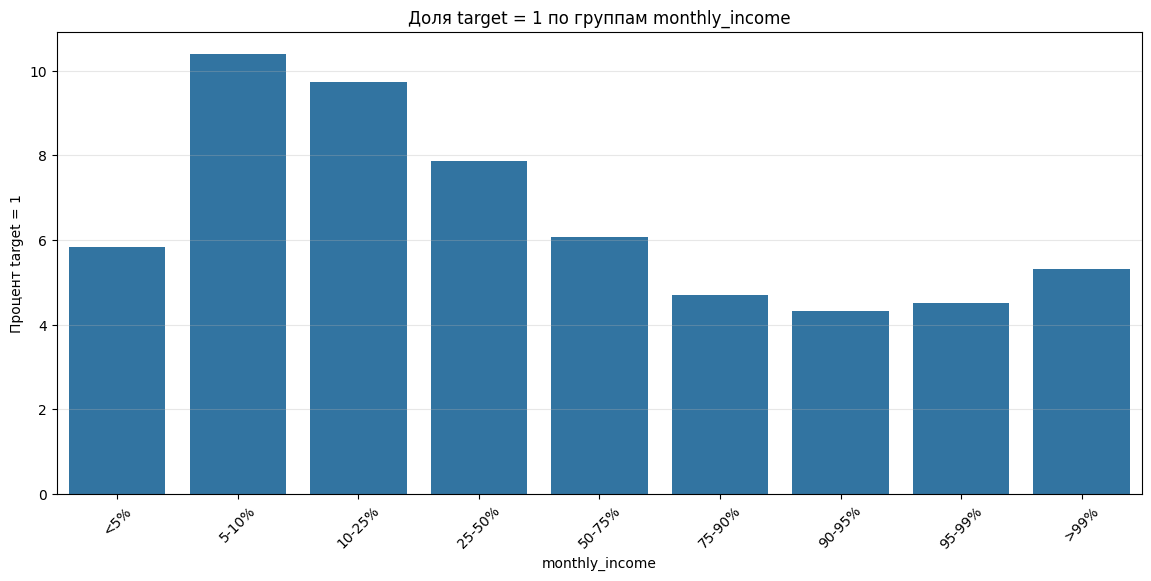

In [452]:
bins = [0, 1300, 2029, 3400, 5400, 8250, 11666, 14591.1, 25000, np.inf]
labels = ["<5%", "5-10%", "10-25%", "25-50%", "50-75%", "75-90%", "90-95%", "95-99%", ">99%"]

temp = data.copy(deep=True).fillna(0)
temp["monthly_income_bin"] = pd.cut(
    x=temp["monthly_income"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

monthly_income_summary = (
    temp
    .groupby("monthly_income_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
monthly_income_summary["target_1_pct"] = monthly_income_summary["target_1_rate"] * 100
monthly_income_summary["CI_bin"] = monthly_income_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
monthly_income_summary["target_1_pct_all"] = data["target"].mean() * 100
monthly_income_summary["lift"] = monthly_income_summary["target_1_pct"] - (data["target"].mean() * 100)
monthly_income_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=monthly_income_summary,
    x="monthly_income_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам monthly_income")
plt.xlabel("monthly_income")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [453]:
monthly_income_summary[
    [
        "monthly_income_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,monthly_income_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,<5%,35329,5.8252,6.6983,-0.8731,0.0559 - 0.0607,0.0656 - 0.0681
1,5-10%,5905,10.3980,6.6983,3.6997,0.0965 - 0.1120,0.0656 - 0.0681
2,10-25%,18170,9.7303,6.6983,3.0320,0.0931 - 0.1017,0.0656 - 0.0681
3,25-50%,30023,7.8606,6.6983,1.1623,0.0756 - 0.0817,0.0656 - 0.0681
4,50-75%,29961,6.0712,6.6983,-0.6271,0.0581 - 0.0635,0.0656 - 0.0681
5,75-90%,18083,4.7116,6.6983,-1.9867,0.0441 - 0.0503,0.0656 - 0.0681
6,90-95%,5899,4.3228,6.6983,-2.3755,0.0383 - 0.0487,0.0656 - 0.0681
7,95-99%,4843,4.5013,6.6983,-2.1970,0.0395 - 0.0512,0.0656 - 0.0681
8,>99%,1168,5.3082,6.6983,-1.3901,0.0416 - 0.0675,0.0656 - 0.0681


Я бы сказал, что большой линейной связи нет. Скорее можно сказать, что граждане имеющие доходы выше низкого и ниже среднего имеют больше просрочек, чем остальные категории.

**Вывод по значениям признака:**
1. В целом можно сказать, что в признаке нет ошибочных значений среди эксремальных значений;
2. В признаке явно есть выбросы - огромные значения, которые нужно как-то обработать;
3. Большой связи с target у признака, только лишь то, что граждане имеющие доход между низким и среднем чащес имеют проблемы с просрочками в будущем.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. Выполнить логарифмирование признака, для выравнивания масштаба значений;
2. Выполнить бинаризацию признака.

In [454]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "monthly_income",
    "Небольшая обратная линейная связь",
    "Да",
    "Либо потеря дохода, либо доход недекларирован",
    "Значительная связь отсутствует",
    "Да",
    "Ошибки отсутвуют, просто большие значения",
    "Небольшая обратная линейная связь",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. Выполнить логарифмирование признака, для выравнивания масштаба значений;\n2. Выполнить бинаризацию признака."
]

## `num_open_credit_lines`

**Обзор признака**

Признак `num_open_credit_lines` означает количество открытых кредитов, например автокредит или ипотека, и кредитных линий, например, кредитных карт. То есть это просто общее количество кредитов и кредитных линий.

Исходя из смысла признака стоит ожидать небольшые значения, отрицательных быть не может. В принципе и большие значения возможны, но, тогда это должны быть состоятельные клиенты, для которых банки готовы открыть много кредитных линий, либо люди, которые открыли кредитные линии во многих банках.

**Анализ значений признака**

Количественные характеристики признака

In [455]:
features_values_analysis.loc["num_open_credit_lines"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             2.0000
10%            3.0000
25%            5.0000
mean           8.4809
std            5.1365
50%            8.0000
75%           11.0000
90%           15.0000
95%           18.0000
99%           24.0000
99.5%         27.0000
max           58.0000
gamma1         1.2218
gamma2         3.1173
Name: num_open_credit_lines, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [456]:
data.query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "99%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
80160,0,0.2903,73,0,0.7950,"4,916.0000",26,0,2,0,1.0000
149839,0,0.0117,51,0,0.0108,"37,500.0000",48,0,0,0,0.0000
9463,0,0.6048,52,0,0.5952,"14,916.0000",46,0,3,0,0.0000
65050,0,0.0171,64,0,0.1778,"11,587.0000",25,0,1,0,0.0000
82363,0,0.1578,61,0,0.5421,"5,470.0000",29,0,2,0,0.0000
120454,0,0.0457,47,0,1.0208,"4,333.0000",33,0,2,0,0.0000
136038,0,0.3581,71,0,0.7295,"3,700.0000",34,0,1,0,0.0000
86126,0,0.5414,66,0,0.4710,"2,963.0000",26,1,2,0,0.0000
5313,0,0.0319,60,0,0.2184,"7,010.0000",28,0,1,0,0.0000
75439,0,0.3678,50,0,0.7570,"6,280.0000",26,0,3,0,0.0000


In [457]:
data.query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
55655,0,0.0094,63,0,0.7206,"4,000.0000",48,0,2,0,0.0000
127428,0,0.0465,25,0,0.1691,"4,499.0000",30,0,0,0,0.0000
71298,0,0.1224,59,0,0.2764,"10,747.0000",28,0,2,0,0.0000
41420,0,0.2863,58,0,0.3364,"7,044.0000",28,0,1,0,3.0000
55588,0,0.0011,49,0,0.0731,"6,250.0000",31,0,0,0,0.0000
87532,0,0.1520,50,0,0.1176,"4,039.0000",32,0,0,0,0.0000
16246,0,0.0007,60,0,0.4818,"4,100.0000",34,0,2,0,0.0000
143038,0,0.1542,43,0,0.3184,"5,417.0000",28,0,0,0,0.0000
68256,0,0.2006,70,0,"3,640.0000",NaN,31,0,3,0,0.0000
56987,0,0.5554,57,0,0.4810,"10,407.0000",28,0,3,0,4.0000


В целом есть явно проблемные объекты: низкий или отсутствующий доход, высокий `debt_ratio` и большое число открытых кредитных линий. Это явно странно, а скорее всего неадекватно в принципе.

Посмотрим на распределение признаков с экстемальными `num_open_credit_lines`.

In [458]:
(
    data
    .drop(columns="target")
    .query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "90%"]}")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "mean", "std", "0.5%", "1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,mean,std,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,"13,826.0000",0.0000,0.9659,68.2491,0.0000,0.0000,0.0031,0.0097,0.0413,0.1661,0.4181,0.7043,0.8566,0.9921,1.0355,"7,809.0000"
age,"13,826.0000",22.0000,56.3873,11.4152,29.0000,31.0000,37.0000,41.0000,49.0000,57.0000,64.0000,71.0000,76.0000,83.7500,86.0000,109.0000
num_30_59_days_late,"13,826.0000",0.0000,0.3463,0.8739,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,5.0000,11.0000
debt_ratio,"13,826.0000",0.0000,547.6273,"3,216.0390",0.0043,0.0091,0.1077,0.1814,0.3015,0.4794,0.8389,"1,987.0000","3,740.0000","7,869.5000","10,734.6250","307,001.0000"
monthly_income,"11,955.0000",0.0000,"8,930.5582","11,107.8739",0.0000,1.0000,"2,400.0000","3,230.0000","4,907.5000","7,249.0000","10,500.0000","15,000.0000","19,000.0000","38,325.4400","53,115.0000","730,483.0000"
num_open_credit_lines,"13,826.0000",16.0000,19.5984,4.2321,16.0000,16.0000,16.0000,16.0000,17.0000,18.0000,21.0000,25.0000,28.0000,35.0000,40.0000,58.0000
num_90_days_late,"13,826.0000",0.0000,0.0391,0.3346,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,14.0000
num_real_estate_loans,"13,826.0000",0.0000,1.9085,1.8617,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,3.0000,5.0000,9.0000,11.8750,54.0000
num_60_89_days_late,"13,826.0000",0.0000,0.0547,0.3317,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,11.0000
num_dependents,"13,711.0000",0.0000,0.8139,1.1103,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,4.0000,5.0000,8.0000


В целом видно, что люди с большим числом открытых линий как правило богаты и не отдают на кредиты последние деньги, но есть и исключения.

Посмотрим ещё количество людей с нулевым или отсутствующим доходом и большим количеством открытых кредитных линий.

In [459]:
temp = data.query(f"num_open_credit_lines > {features_values_analysis.loc["num_open_credit_lines", "90%"]}")

temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)").shape[0] / temp.shape[0]

0.14234051786489224

In [460]:
temp = temp.query("(not monthly_income.notna()) or (monthly_income < 10e-6)")

temp.query("target == 1").shape[0] / temp.shape[0] * 100

5.386178861788618

Очень странные данные. Примерно 14 процентов людей с большим числом кредитных линий не имеют доход. Кроме того, у таких людей не было проблем с кредитами в следующие 2 года, что странновато.

Возможное объяснение кроется в том, что человек, набравший кредитов и неотдавший их, испортил свою кредитную историю и, отсутствие просрочек, объясняется отсутствием кредитов, по которым они могли быть.

Стоит ещё сказать, что возможно это просто люди, потерявшие свой доход или взявшие необеспеченные кредитные линии (кридитки выдают людям и без дохода), так что я бы не стал считать такие данные ошибочными.

Посмотрим ещё на связь признака с целевой переменной.

In [461]:
features_values_analysis.loc["num_open_credit_lines"][["1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%"]]

1%     0.0000
5%     2.0000
10%    3.0000
25%    5.0000
50%    8.0000
75%   11.0000
90%   15.0000
95%   18.0000
99%   24.0000
Name: num_open_credit_lines, dtype: float64

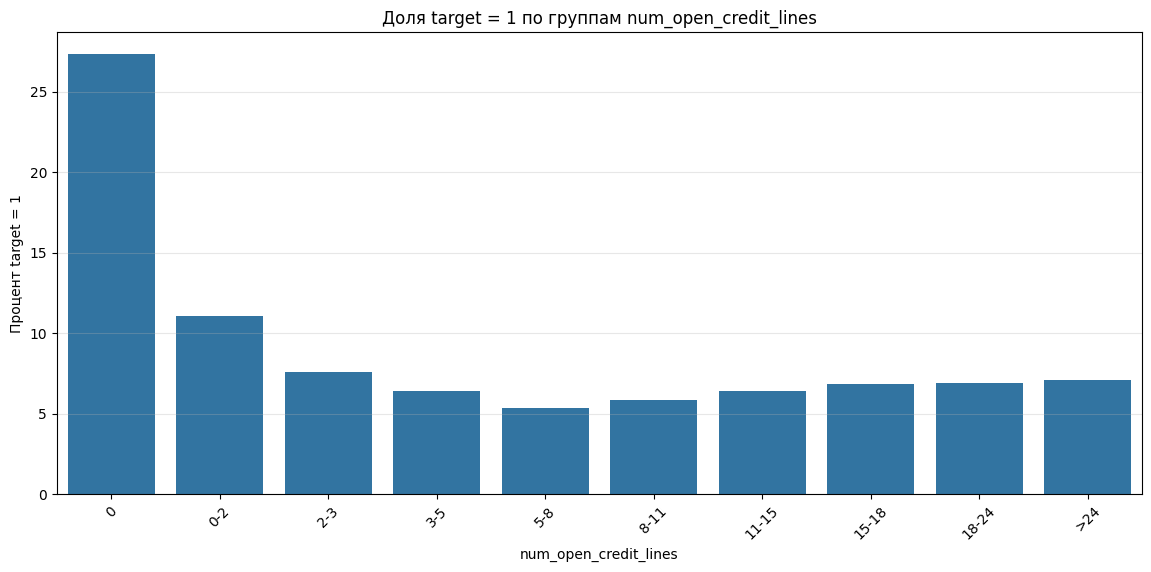

In [462]:
bins = [-np.inf, 0, 2, 3, 5, 8, 11, 15, 18, 24, np.inf]
labels = ["0", "0-2", "2-3", "3-5", "5-8", "8-11", "11-15", "15-18", "18-24", ">24"]

temp = data.copy(deep=True).fillna(0)
temp["num_open_credit_lines_bin"] = pd.cut(
    x=temp["num_open_credit_lines"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_open_credit_lines_summary = (
    temp
    .groupby("num_open_credit_lines_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_open_credit_lines_summary["target_1_pct"] = num_open_credit_lines_summary["target_1_rate"] * 100
num_open_credit_lines_summary["CI_bin"] = num_open_credit_lines_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_open_credit_lines_summary["target_1_pct_all"] = data["target"].mean() * 100
num_open_credit_lines_summary["lift"] = num_open_credit_lines_summary["target_1_pct"] - (data["target"].mean() * 100)
num_open_credit_lines_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_open_credit_lines_summary,
    x="num_open_credit_lines_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_open_credit_lines")
plt.xlabel("num_open_credit_lines")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [463]:
num_open_credit_lines_summary[
    [
        "num_open_credit_lines_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_open_credit_lines_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0,1702,27.3208,6.6983,20.6225,0.2526 - 0.2949,0.0656 - 0.0681
1,0-2,10809,11.0371,6.6983,4.3388,0.1046 - 0.1164,0.0656 - 0.0681
2,2-3,8992,7.5845,6.6983,0.8862,0.0706 - 0.0815,0.0656 - 0.0681
3,3-5,24482,6.3802,6.6983,-0.3181,0.0608 - 0.0669,0.0656 - 0.0681
4,5-8,39408,5.3466,6.6983,-1.3517,0.0513 - 0.0557,0.0656 - 0.0681
5,8-11,29299,5.8330,6.6983,-0.8653,0.0557 - 0.0611,0.0656 - 0.0681
6,11-15,20863,6.3893,6.6983,-0.3090,0.0607 - 0.0673,0.0656 - 0.0681
7,15-18,7244,6.8470,6.6983,0.1487,0.0629 - 0.0745,0.0656 - 0.0681
8,18-24,5106,6.9330,6.6983,0.2347,0.0627 - 0.0766,0.0656 - 0.0681
9,>24,1476,7.1138,6.6983,0.4155,0.0591 - 0.0854,0.0656 - 0.0681


Я бы сказал, что присутствует нелинейная связь.

**Вывод по значениям признака:**

1. Большинство людей имеют не более 15 кредитных открытых линий;
2. Большинство выбросов не являются ошибочными: богатые и состоятельные клиенты с большим числом кредитных линий, либо просто люди потерявшие доход, либо люди с необеспеченными кредитами;
3. Некоторые выбросы, возможно, являются ошибками - незакрытые кредитные линии, которые не были убраны из базы, но это, к сожалению, не отследить по данному датасету.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. выполнить логарифмирование признака для выравнивания масштаба признака;
2. выполнить бинаризацию признака.

In [464]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "num_open_credit_lines",
    "Присутствует некоторая нелинейная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Ошибки отсутвуют, просто большие значения",
    "Отсутствует",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. выполнить логарифмирование признака для выравнивания масштаба признака;\n2. выполнить бинаризацию признака."
]

## `num_real_estate_loans`

**Обзор признака**

Признак `num_real_estate_loans` означает количество ипотечных и других кредитов, связанных с недвижимостью, включая кредитные линии под залог жилья.

Исходя из смысла признака стоит ожидать малых значений признака, все большие значения, вероятно будут являться ошибочными.

**Анализ значений признака**

Количественные характеристики признака

In [465]:
features_values_analysis.loc["num_real_estate_loans"]

count    149,391.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             0.0000
10%            0.0000
25%            0.0000
mean           1.0224
std            1.1302
50%            1.0000
75%            2.0000
90%            2.0000
95%            3.0000
99%            4.0000
99.5%          6.0000
max           54.0000
gamma1         3.4847
gamma2        60.5859
Name: num_real_estate_loans, dtype: float64

Беглый осмотр данных с аномальными значениями признака

In [466]:
data.query(f"num_real_estate_loans > {features_values_analysis.loc["num_real_estate_loans", "99.5%"]}").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
99333,0,0.0114,53,0,0.9127,"8,400.0000",10,0,7,1,0.0000
72740,0,0.4277,62,0,1.1723,"7,166.0000",32,0,9,0,0.0000
65728,1,0.0369,43,0,0.7192,"55,966.0000",41,0,29,0,0.0000
4797,1,0.9630,39,2,3.1734,"5,916.0000",19,0,12,0,2.0000
62890,0,0.0171,34,0,0.9203,"15,000.0000",17,0,7,0,3.0000
28065,0,0.6241,39,0,0.9627,"6,333.0000",15,0,7,0,3.0000
134424,0,0.1885,74,0,0.7813,"6,400.0000",23,0,9,0,1.0000
81080,0,0.0156,66,0,"7,131.0000",NaN,31,0,9,0,0.0000
116245,0,0.0120,57,1,0.7110,"19,250.0000",21,0,12,0,0.0000
29059,0,0.4313,65,4,0.6804,"18,333.0000",29,0,8,0,0.0000


In [467]:
(
    data
    .query(f"num_real_estate_loans > {features_values_analysis.loc["num_real_estate_loans", "99.5%"]}")
    .sort_values(by="num_real_estate_loans")
    .tail(20)
)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
63506,0,0.6106,50,1,0.3234,"65,000.0000",24,0,17,0,0.0000
74368,0,0.0289,58,0,1.0588,"11,264.0000",32,0,17,0,1.0000
2495,1,0.4514,48,0,2.5120,"12,080.0000",29,0,17,0,2.0000
47172,0,0.1291,62,0,"14,136.0000",NaN,29,0,17,0,0.0000
36922,0,0.0654,67,0,3.4894,"10,000.0000",29,0,18,0,0.0000
128995,0,0.0086,57,1,"8,678.0000",NaN,26,0,18,0,1.0000
123341,0,0.9446,57,1,0.7228,"20,500.0000",29,0,19,0,0.0000
94068,0,0.3241,53,0,0.6023,"19,500.0000",34,0,19,0,3.0000
141114,0,0.7151,47,0,0.6716,"24,883.0000",40,0,20,0,2.0000
98386,1,0.5243,60,4,0.8651,"18,131.0000",24,0,20,0,0.0000


Посмотрим на распределение признаков у данных с большими значениями `num_real_estate_loans`.

In [468]:
(
    data
    .drop(columns="target")
    .query(f"num_real_estate_loans > {features_values_analysis.loc["num_real_estate_loans", "99.5%"]}")
    .describe(percentiles=[0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "mean", "std", "0.5%", "1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,mean,std,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
revolving_utilization,473.0000,0.0000,4.2300,85.0952,0.0000,0.0000,0.0000,0.0038,0.0471,0.2004,0.4960,0.8326,0.9439,1.0766,1.2950,"1,851.0000"
age,473.0000,27.0000,53.2875,11.1009,30.7200,32.0000,36.6000,40.0000,45.0000,52.0000,62.0000,68.0000,73.0000,78.2800,81.6400,87.0000
num_30_59_days_late,473.0000,0.0000,0.5962,1.2887,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,6.2800,7.6400,8.0000
debt_ratio,473.0000,0.0936,"1,983.7675","5,333.8163",0.1795,0.2392,0.3426,0.4226,0.5941,0.9224,2.0460,"8,728.4000","13,385.0000","22,241.9200","25,886.0800","52,112.0000"
monthly_income,398.0000,0.0000,"16,138.6256","20,785.0938",0.9850,"1,985.0000","3,872.9500","5,108.9000","7,792.0000","12,408.0000","18,079.5000","25,369.3000","40,112.5000","73,766.1600","101,927.3200","324,000.0000"
num_open_credit_lines,473.0000,7.0000,19.3087,6.6611,9.0000,9.0000,11.0000,12.0000,15.0000,18.0000,23.0000,28.0000,31.4000,40.2800,42.0000,58.0000
num_90_days_late,473.0000,0.0000,0.0761,0.7325,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.6400,14.0000
num_real_estate_loans,473.0000,7.0000,9.3214,3.9298,7.0000,7.0000,7.0000,7.0000,7.0000,8.0000,10.0000,13.0000,15.4000,25.0000,27.9200,54.0000
num_60_89_days_late,473.0000,0.0000,0.1015,0.5951,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.2800,4.2800,8.0000
num_dependents,469.0000,0.0000,0.9467,1.2841,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,3.0000,5.0000,5.6600,6.0000


В целом видно, что большинство людей с большим числом кредитов под залог жилья - это состоятельные люди. Однако с `debt_ratio` тут всё хуже, чем с `num_open_credit_lines`, думаю, это объясняется тем, что у таких людей много недвижимости, которая и занимает значительную часть `debt_ratio`.

Посмотрим ещё на представителей с `debt_ratio` > 2 и `num_real_estate_loans` > 0.

In [469]:
data.query("(debt_ratio > 2.0) and (num_real_estate_loans > 0)").sample(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
64438,0,0.5521,58,0,"2,785.0000",NaN,6,0,1,0,0.0000
41427,0,0.0328,54,1,"15,588.0000",NaN,19,0,4,0,0.0000
69170,0,0.0922,72,0,"2,211.0000",NaN,4,0,1,0,NaN
14401,0,0.0048,69,0,"5,390.0000",NaN,24,0,3,0,0.0000
97553,0,0.0000,60,0,"1,125.0000",NaN,7,0,1,0,0.0000
78336,0,0.5905,40,0,"4,953.0000",NaN,19,0,1,0,0.0000
124402,0,0.0031,80,0,"1,482.0000",NaN,12,0,1,0,NaN
80288,0,0.9778,50,0,2.5327,"5,148.0000",11,0,2,0,3.0000
99525,0,0.0582,71,0,"3,083.0000",NaN,8,0,1,0,0.0000
132471,0,0.0000,55,0,"4,289.0000",NaN,12,0,3,0,0.0000


И ещё посмотрим на распределение некоторых признаков.

In [470]:
(
    data
    .drop(columns="target")
    .query("(debt_ratio > 2.0) and (num_real_estate_loans > 0)")
    [["debt_ratio", "monthly_income", "num_30_59_days_late", "num_60_89_days_late", "num_90_days_late", "num_real_estate_loans"]]
    .describe(percentiles=[0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    .T
)[["count", "min", "mean", "std", "0.5%", "1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%", "99.5%", "max"]]

,count,min,mean,std,0.5%,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.5%,max
debt_ratio,"19,188.0000",2.0004,"2,507.0277","4,995.6937",2.0952,2.2261,7.4974,644.7000,"1,249.0000","2,025.5000","3,114.0000","4,542.0000","5,714.0000","9,564.3900","11,988.4550","329,664.0000"
monthly_income,"2,215.0000",0.0000,"1,048.5409","2,206.7799",0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,"1,183.5000","2,800.0000","5,000.0000","11,930.0000","14,042.7800","25,800.0000"
num_30_59_days_late,"19,188.0000",0.0000,0.2144,0.6625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,3.0000,4.0000,10.0000
num_60_89_days_late,"19,188.0000",0.0000,0.0485,0.2840,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,9.0000
num_90_days_late,"19,188.0000",0.0000,0.0548,0.3668,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000,11.0000
num_real_estate_loans,"19,188.0000",1.0000,1.5651,1.1003,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,3.0000,5.0000,7.0000,54.0000


Исходя из данных, можно предположить, что высокий `monthly_income` для людей с кредитами под залог жилья означает долг в абсолютном значении, а отсутствие просрочек, скорее всего, говорит о том, что это долг не за кредит, а за кварплату.

Таким ообразом, я думаю, что в признаке ошибок нет.

Посмотрим теперь на корреляцию таргета с признаком.

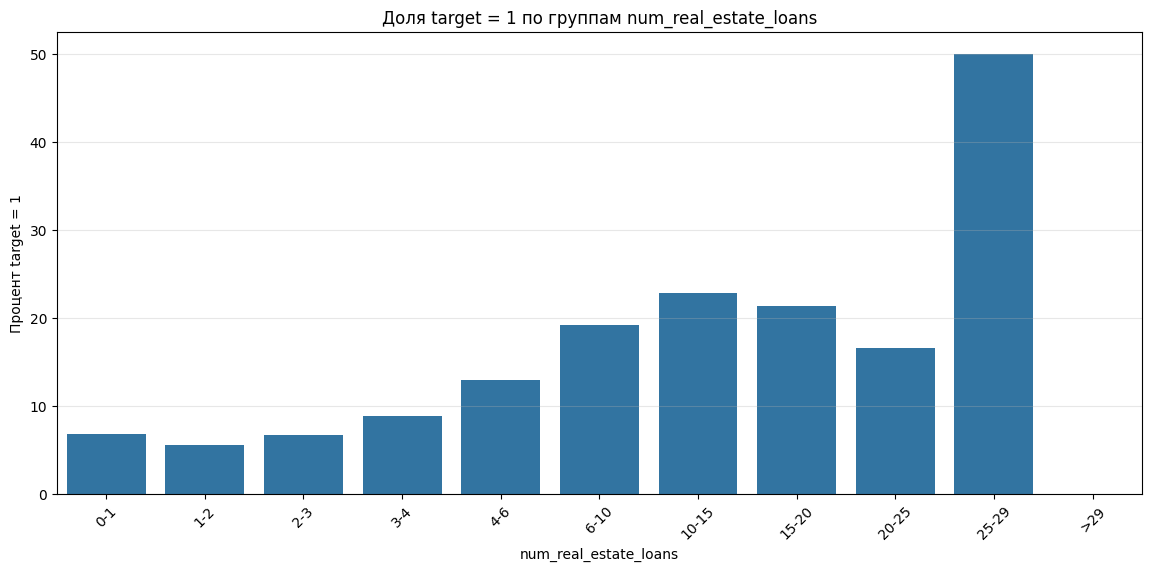

In [471]:
bins = [0, 1, 2, 3, 4, 6, 10, 15, 20, 25, 29, np.inf]
labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-10", "10-15", "15-20", "20-25", "25-29", ">29"]

temp = data.copy(deep=True).fillna(0)
temp["num_real_estate_loans_bin"] = pd.cut(
    x=temp["num_real_estate_loans"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_real_estate_loans_summary = (
    temp
    .groupby("num_real_estate_loans_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_real_estate_loans_summary["target_1_pct"] = num_real_estate_loans_summary["target_1_rate"] * 100
num_real_estate_loans_summary["CI_bin"] = num_real_estate_loans_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_real_estate_loans_summary["target_1_pct_all"] = data["target"].mean() * 100
num_real_estate_loans_summary["lift"] = num_real_estate_loans_summary["target_1_pct"] - (data["target"].mean() * 100)
num_real_estate_loans_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_real_estate_loans_summary,
    x="num_real_estate_loans_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_real_estate_loans")
plt.xlabel("num_real_estate_loans")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [472]:
num_real_estate_loans_summary[
    [
        "num_real_estate_loans_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_real_estate_loans_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,0-1,107907,6.8578,6.6983,0.1594,0.0671 - 0.0701,0.0656 - 0.0681
1,1-2,31522,5.5993,6.6983,-1.0990,0.0535 - 0.0586,0.0656 - 0.0681
2,2-3,6300,6.6984,6.6983,0.0001,0.0611 - 0.0734,0.0656 - 0.0681
3,3-4,2170,8.9401,6.6983,2.2418,0.0781 - 0.1021,0.0656 - 0.0681
4,4-6,1009,12.9832,6.6983,6.2848,0.1105 - 0.1520,0.0656 - 0.0681
5,6-10,379,19.2612,6.6983,12.5629,0.1561 - 0.2353,0.0656 - 0.0681
6,10-15,70,22.8571,6.6983,16.1588,0.1459 - 0.3395,0.0656 - 0.0681
7,15-20,14,21.4286,6.6983,14.7303,0.0757 - 0.4759,0.0656 - 0.0681
8,20-25,6,16.6667,6.6983,9.9684,0.0301 - 0.5635,0.0656 - 0.0681
9,25-29,2,50.0000,6.6983,43.3017,0.0945 - 0.9055,0.0656 - 0.0681


Видно, что присутствует значительная нелинейная связь.

Посмотрим ещё на связь `num_real_estate_loans` с пропусками.

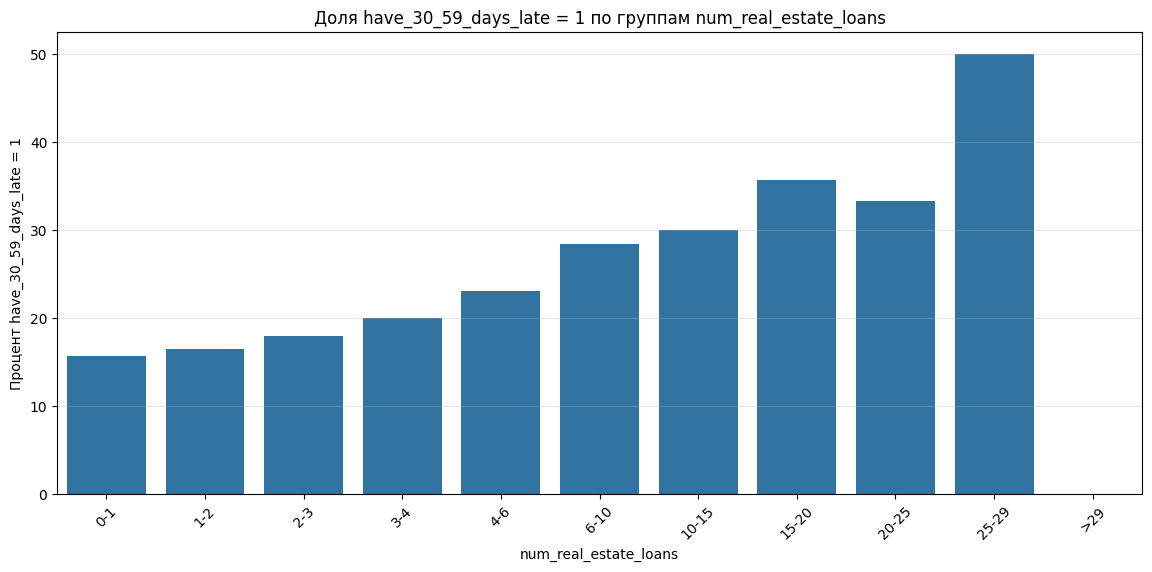

In [473]:
bins = [0, 1, 2, 3, 4, 6, 10, 15, 20, 25, 29, np.inf]
labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-10", "10-15", "15-20", "20-25", "25-29", ">29"]

temp = data.copy(deep=True).fillna(0)
temp["num_real_estate_loans_bin"] = pd.cut(
    x=temp["num_real_estate_loans"],
    bins=bins,
    labels=labels,
    right=True
)
temp["have_30_59_days_late"] = (temp["num_30_59_days_late"] > 0).astype(int) 

num_real_estate_loans_summary = (
    temp
    .groupby("num_real_estate_loans_bin")
    .agg(
        count=("have_30_59_days_late", "size"),
        have_30_59_days_late_count=("have_30_59_days_late", "sum"),
        have_30_59_days_late_rate=("have_30_59_days_late", "mean")
    )
    .reset_index()
)
num_real_estate_loans_summary["have_30_59_days_late_pct"] = num_real_estate_loans_summary["have_30_59_days_late_rate"] * 100
num_real_estate_loans_summary["CI_late_30_59_bin"] = num_real_estate_loans_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["have_30_59_days_late_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_real_estate_loans_summary["have_30_59_days_late_pct_all"] = temp["have_30_59_days_late"].mean() * 100
num_real_estate_loans_summary["lift_have_30_59_days_late_pct"] =\
    num_real_estate_loans_summary["have_30_59_days_late_pct"] - num_real_estate_loans_summary["have_30_59_days_late_pct_all"]
num_real_estate_loans_summary["CI_late_30_59_all"] =\
    "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=temp["have_30_59_days_late"].sum(),
        nobs=temp["have_30_59_days_late"].shape[0],
        alpha=0.05,
        method="wilson"
    ))

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_real_estate_loans_summary,
    x="num_real_estate_loans_bin",
    y="have_30_59_days_late_pct"
)

plt.title("Доля have_30_59_days_late = 1 по группам num_real_estate_loans")
plt.xlabel("num_real_estate_loans")
plt.ylabel("Процент have_30_59_days_late = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [474]:
num_real_estate_loans_summary[
    [
        "num_real_estate_loans_bin",
        "count",
        "have_30_59_days_late_pct",
        "have_30_59_days_late_pct_all",
        "lift_have_30_59_days_late_pct",
        "CI_late_30_59_bin",
        "CI_late_30_59_all"
    ]
]

,num_real_estate_loans_bin,count,have_30_59_days_late_pct,have_30_59_days_late_pct_all,lift_have_30_59_days_late_pct,CI_late_30_59_bin,CI_late_30_59_all
0,0-1,52338,15.6617,16.0248,-0.3631,0.1535 - 0.1598,0.1584 - 0.1621
1,1-2,31522,16.5535,16.0248,0.5287,0.1615 - 0.1697,0.1584 - 0.1621
2,2-3,6300,18.0317,16.0248,2.0070,0.1710 - 0.1900,0.1584 - 0.1621
3,3-4,2170,20.0000,16.0248,3.9752,0.1837 - 0.2174,0.1584 - 0.1621
4,4-6,1009,23.0922,16.0248,7.0674,0.2060 - 0.2579,0.1584 - 0.1621
5,6-10,379,28.4960,16.0248,12.4712,0.2419 - 0.3324,0.1584 - 0.1621
6,10-15,70,30.0000,16.0248,13.9752,0.2054 - 0.4154,0.1584 - 0.1621
7,15-20,14,35.7143,16.0248,19.6895,0.1634 - 0.6124,0.1584 - 0.1621
8,20-25,6,33.3333,16.0248,17.3085,0.0968 - 0.7000,0.1584 - 0.1621
9,25-29,2,50.0000,16.0248,33.9752,0.0945 - 0.9055,0.1584 - 0.1621


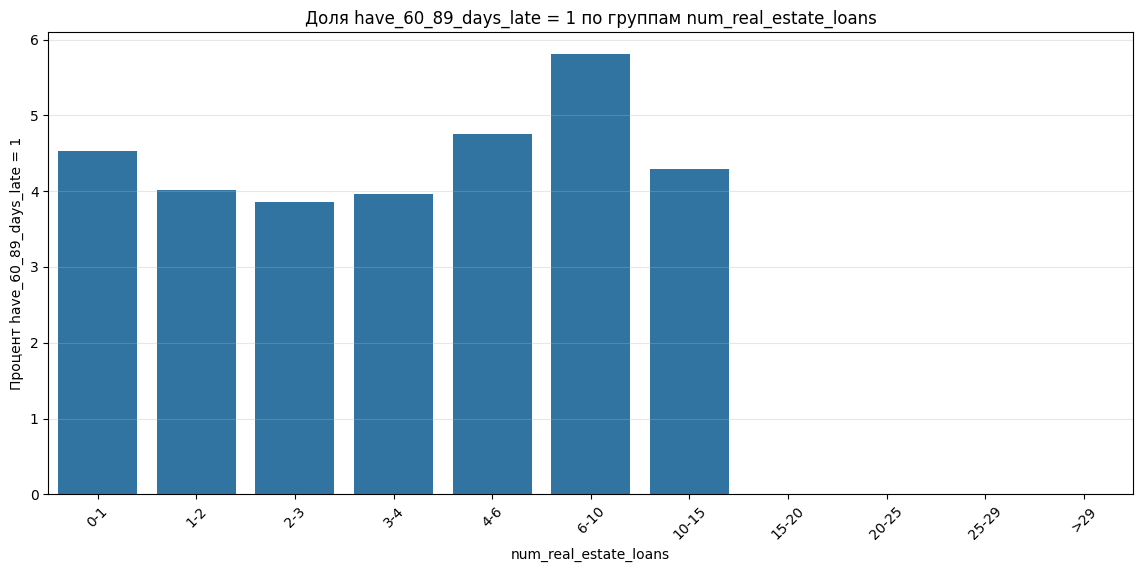

In [475]:
bins = [0, 1, 2, 3, 4, 6, 10, 15, 20, 25, 29, np.inf]
labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-10", "10-15", "15-20", "20-25", "25-29", ">29"]

temp = data.copy(deep=True).fillna(0)
temp["num_real_estate_loans_bin"] = pd.cut(
    x=temp["num_real_estate_loans"],
    bins=bins,
    labels=labels,
    right=True
)
temp["have_60_89_days_late"] = (temp["num_60_89_days_late"] > 0).astype(int) 

num_real_estate_loans_summary = (
    temp
    .groupby("num_real_estate_loans_bin")
    .agg(
        count=("have_60_89_days_late", "size"),
        have_60_89_days_late_count=("have_60_89_days_late", "sum"),
        have_60_89_days_late_rate=("have_60_89_days_late", "mean")
    )
    .reset_index()
)
num_real_estate_loans_summary["have_60_89_days_late_pct"] = num_real_estate_loans_summary["have_60_89_days_late_rate"] * 100
num_real_estate_loans_summary["CI_late_60_89_bin"] = num_real_estate_loans_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["have_60_89_days_late_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_real_estate_loans_summary["have_60_89_days_late_pct_all"] = temp["have_60_89_days_late"].mean() * 100
num_real_estate_loans_summary["lift_have_60_89_days_late_pct"] =\
    num_real_estate_loans_summary["have_60_89_days_late_pct"] - num_real_estate_loans_summary["have_60_89_days_late_pct_all"]
num_real_estate_loans_summary["CI_late_60_89_all"] =\
    "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=temp["have_60_89_days_late"].sum(),
        nobs=temp["have_60_89_days_late"].shape[0],
        alpha=0.05,
        method="wilson"
    ))

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_real_estate_loans_summary,
    x="num_real_estate_loans_bin",
    y="have_60_89_days_late_pct"
)

plt.title("Доля have_60_89_days_late = 1 по группам num_real_estate_loans")
plt.xlabel("num_real_estate_loans")
plt.ylabel("Процент have_60_89_days_late = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [476]:
num_real_estate_loans_summary[
    [
        "num_real_estate_loans_bin",
        "count",
        "have_60_89_days_late_pct",
        "have_60_89_days_late_pct_all",
        "lift_have_60_89_days_late_pct",
        "CI_late_60_89_bin",
        "CI_late_60_89_all"
    ]
]

,num_real_estate_loans_bin,count,have_60_89_days_late_pct,have_60_89_days_late_pct_all,lift_have_60_89_days_late_pct,CI_late_60_89_bin,CI_late_60_89_all
0,0-1,52338,4.5302,5.0602,-0.5300,0.0436 - 0.0471,0.0495 - 0.0517
1,1-2,31522,4.0099,5.0602,-1.0503,0.0380 - 0.0423,0.0495 - 0.0517
2,2-3,6300,3.8571,5.0602,-1.2031,0.0341 - 0.0436,0.0495 - 0.0517
3,3-4,2170,3.9631,5.0602,-1.0971,0.0322 - 0.0487,0.0495 - 0.0517
4,4-6,1009,4.7572,5.0602,-0.3030,0.0361 - 0.0625,0.0495 - 0.0517
5,6-10,379,5.8047,5.0602,0.7445,0.0386 - 0.0863,0.0495 - 0.0517
6,10-15,70,4.2857,5.0602,-0.7745,0.0147 - 0.1186,0.0495 - 0.0517
7,15-20,14,0.0000,5.0602,-5.0602,0.0000 - 0.2153,0.0495 - 0.0517
8,20-25,6,0.0000,5.0602,-5.0602,0.0000 - 0.3903,0.0495 - 0.0517
9,25-29,2,0.0000,5.0602,-5.0602,0.0000 - 0.6576,0.0495 - 0.0517


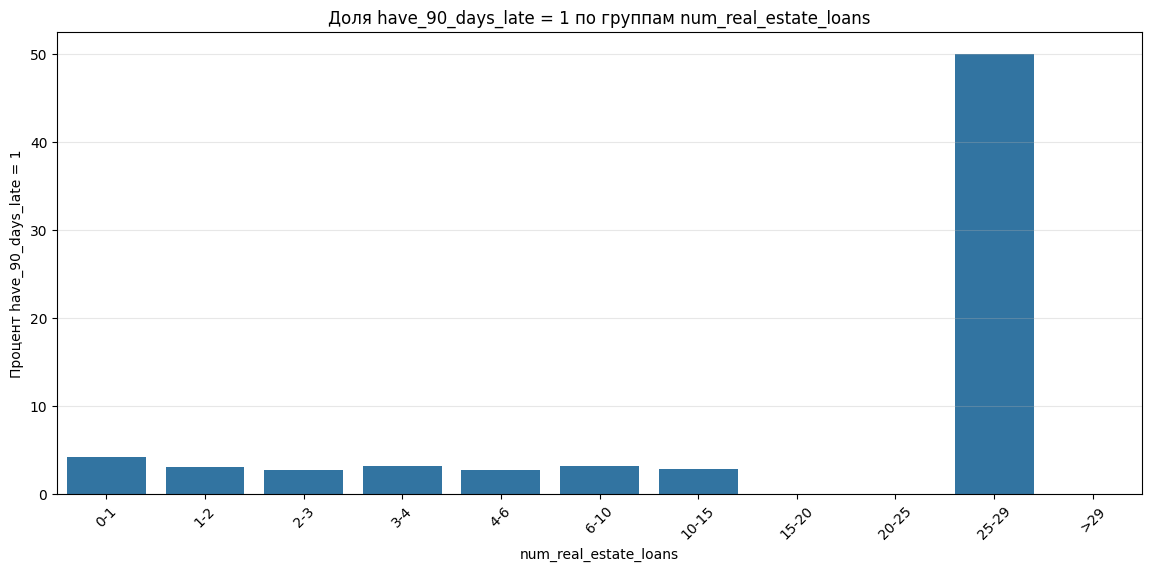

In [477]:
bins = [0, 1, 2, 3, 4, 6, 10, 15, 20, 25, 29, np.inf]
labels = ["0-1", "1-2", "2-3", "3-4", "4-6", "6-10", "10-15", "15-20", "20-25", "25-29", ">29"]

temp = data.copy(deep=True).fillna(0)
temp["num_real_estate_loans_bin"] = pd.cut(
    x=temp["num_real_estate_loans"],
    bins=bins,
    labels=labels,
    right=True
)
temp["have_90_days_late"] = (temp["num_90_days_late"] > 0).astype(int) 

num_real_estate_loans_summary = (
    temp
    .groupby("num_real_estate_loans_bin")
    .agg(
        count=("have_90_days_late", "size"),
        have_90_days_late_count=("have_90_days_late", "sum"),
        have_90_days_late_rate=("have_90_days_late", "mean")
    )
    .reset_index()
)
num_real_estate_loans_summary["have_90_days_late_pct"] = num_real_estate_loans_summary["have_90_days_late_rate"] * 100
num_real_estate_loans_summary["CI_late_90_bin"] = num_real_estate_loans_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["have_90_days_late_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_real_estate_loans_summary["have_90_days_late_pct_all"] = temp["have_90_days_late"].mean() * 100
num_real_estate_loans_summary["lift_have_90_days_late_pct"] =\
    num_real_estate_loans_summary["have_90_days_late_pct"] - num_real_estate_loans_summary["have_90_days_late_pct_all"]
num_real_estate_loans_summary["CI_late_90_all"] =\
    "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=temp["have_90_days_late"].sum(),
        nobs=temp["have_90_days_late"].shape[0],
        alpha=0.05,
        method="wilson"
    ))

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_real_estate_loans_summary,
    x="num_real_estate_loans_bin",
    y="have_90_days_late_pct"
)

plt.title("Доля have_90_days_late = 1 по группам num_real_estate_loans")
plt.xlabel("num_real_estate_loans")
plt.ylabel("Процент have_90_days_late = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [478]:
num_real_estate_loans_summary[
    [
        "num_real_estate_loans_bin",
        "count",
        "have_90_days_late_pct",
        "have_90_days_late_pct_all",
        "lift_have_90_days_late_pct",
        "CI_late_90_bin",
        "CI_late_90_all"
    ]
]

,num_real_estate_loans_bin,count,have_90_days_late_pct,have_90_days_late_pct_all,lift_have_90_days_late_pct,CI_late_90_bin,CI_late_90_all
0,0-1,52338,4.2780,5.5382,-1.2602,0.0411 - 0.0445,0.0542 - 0.0566
1,1-2,31522,3.1026,5.5382,-2.4356,0.0292 - 0.0330,0.0542 - 0.0566
2,2-3,6300,2.7619,5.5382,-2.7763,0.0239 - 0.0320,0.0542 - 0.0566
3,3-4,2170,3.2258,5.5382,-2.3124,0.0256 - 0.0406,0.0542 - 0.0566
4,4-6,1009,2.7750,5.5382,-2.7632,0.0193 - 0.0398,0.0542 - 0.0566
5,6-10,379,3.1662,5.5382,-2.3720,0.0182 - 0.0545,0.0542 - 0.0566
6,10-15,70,2.8571,5.5382,-2.6810,0.0079 - 0.0983,0.0542 - 0.0566
7,15-20,14,0.0000,5.5382,-5.5382,0.0000 - 0.2153,0.0542 - 0.0566
8,20-25,6,0.0000,5.5382,-5.5382,0.0000 - 0.3903,0.0542 - 0.0566
9,25-29,2,50.0000,5.5382,44.4618,0.0945 - 0.9055,0.0542 - 0.0566


Такие распределения можно попытаться объяснить следующим образом:
1. Малые просрочки превалируют, так как банки не церемонятся и сразу отнимают заложенное, а потом клиентов банкротят;
2. Длительные просрочки дают реже.
3. Отсутствие просрочек у людей с более, чем 29 кредитами нельзя признать ошибками, так как возможно, это инверсторы.

**Вывод по значениям признака:**
1. Большинство значений не велико < 5;
2. Большее количество кредитов под залог жилья, скорее говорит о том, что человек богаче, у него больше жилья, под залог которого он получает кредиты, также такие люди могут быть инвесторами или тому подобное;
4. В целом признак нормальный, но для линейных моделей его точно стоит логарифмировать;
5. Экстремальные значения нелинейно коррелируют с target и отражают скорее то, что бизнесмены и люди набравшие кредиты под халог жилья больше рискуют и сильнее связаны с риском.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. выполнить логарифмирование признака для выравнивания масштаба значений признака;
2. выполнить бинаризацию признака.

In [479]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "num_real_estate_loans",
    "Присутствует некоторая нелинейная связь.",
    "-",
    "-",
    "-",
    "Да",
    "Ошибки отсутвуют, просто большие значения",
    "Присутствует некоторая нелинейная связь",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. выполнить логарифмирование признака для выравнивания масштаба значений признака;\n2. выполнить бинаризацию признака."
]

## `num_dependents`

**Обзор признака**

Признак `num_dependents` означает количество иждевенцев в семье, исключая самого заёмщика.

Исходя из смысла признака, стоит ожидать небольшие значения.

**Анализ значений признака**

Количественные характеристики признака

In [480]:
features_values_analysis.loc["num_dependents"]

count    145,563.0000
min            0.0000
0.5%           0.0000
1%             0.0000
5%             0.0000
10%            0.0000
25%            0.0000
mean           0.7599
std            1.1161
50%            0.0000
75%            1.0000
90%            2.0000
95%            3.0000
99%            4.0000
99.5%          5.0000
max           20.0000
gamma1         1.5833
gamma2         2.9843
Name: num_dependents, dtype: float64

Беглый осмотр данных с аномальными значениями в признаке

In [481]:
data.query(f"num_dependents > {features_values_analysis.loc["num_dependents", "99.5%"]}").sort_values(by="num_dependents").tail(20)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
144844,1,1.0000,51,1,0.0222,"6,083.0000",3,3,0,0,8.0000
144711,0,0.0079,46,0,0.3864,"9,000.0000",9,0,1,0,8.0000
148688,0,0.0242,56,0,0.0089,"9,583.0000",9,0,0,0,8.0000
130024,0,0.4615,52,0,0.0905,"8,000.0000",9,0,0,0,8.0000
126845,0,1.0000,63,0,0.5464,905.0000,1,0,0,0,8.0000
125592,0,0.0156,40,0,0.4143,"3,750.0000",4,0,2,0,8.0000
99649,0,0.0481,61,1,0.1960,"7,000.0000",7,0,1,0,8.0000
144463,0,0.1128,43,0,0.3592,"7,500.0000",14,0,1,0,8.0000
142803,0,0.1277,48,0,0.2902,"11,400.0000",13,0,2,0,9.0000
137560,0,0.0338,48,0,0.2072,"16,666.0000",8,0,1,0,9.0000


В целом я бы не сказал, что тут есть что-то особенное или заслуживающее внимания.

Посмотрим на корреляцию с целевым признаком

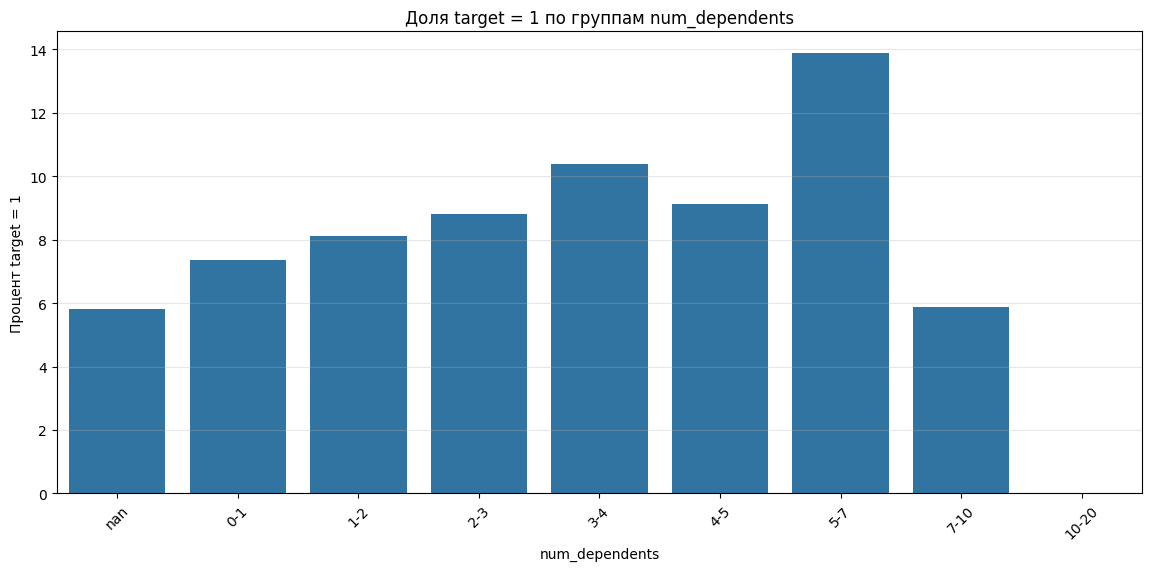

In [482]:
bins = [-1, 0, 1, 2, 3, 4, 5, 7, 10, 20]
labels = ["nan", "0-1", "1-2", "2-3", "3-4", "4-5", "5-7", "7-10", "10-20"]

temp = data.copy(deep=True)
temp["num_dependents"] = temp["num_dependents"].fillna(-1)
temp["num_dependents_bin"] = pd.cut(
    x=temp["num_dependents"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

num_dependents_summary = (
    temp
    .groupby(by="num_dependents_bin")
    .agg(
        count=("target", "size"),
        target_1_count=("target", "sum"),
        target_1_rate=("target", "mean")
    )
    .reset_index()
)
num_dependents_summary["target_1_pct"] = num_dependents_summary["target_1_rate"] * 100
num_dependents_summary["CI_bin"] = num_dependents_summary.apply(
    lambda x: "{0:.4f} - {1:.4f}".format(*proportion_confint(
        count=x["target_1_count"],
        nobs=x["count"],
        alpha=0.05,
        method="wilson"
    )),
    axis=1
)
num_dependents_summary["target_1_pct_all"] = data["target"].mean() * 100
num_dependents_summary["lift"] = num_dependents_summary["target_1_pct"] - (data["target"].mean() * 100)
num_dependents_summary["CI_all"] = f"{ci_low_all:.4f} - {ci_high_all:.4f}"

plt.figure(figsize=(14, 6))

sns.barplot(
    data=num_dependents_summary,
    x="num_dependents_bin",
    y="target_1_pct"
)

plt.title("Доля target = 1 по группам num_dependents")
plt.xlabel("num_dependents")
plt.ylabel("Процент target = 1")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [483]:
num_dependents_summary[
    [
        "num_dependents_bin",
        "count",
        "target_1_pct",
        "target_1_pct_all",
        "lift",
        "CI_bin",
        "CI_all"
    ]
]

,num_dependents_bin,count,target_1_pct,target_1_pct_all,lift,CI_bin,CI_all
0,nan,90211,5.8252,6.6983,-0.8731,0.0567 - 0.0598,0.0656 - 0.0681
1,0-1,26314,7.3535,6.6983,0.6552,0.0704 - 0.0768,0.0656 - 0.0681
2,1-2,19520,8.1096,6.6983,1.4113,0.0773 - 0.0850,0.0656 - 0.0681
3,2-3,9483,8.8263,6.6983,2.1280,0.0827 - 0.0941,0.0656 - 0.0681
4,3-4,2862,10.3774,6.6983,3.6791,0.0931 - 0.1155,0.0656 - 0.0681
5,4-5,746,9.1153,6.6983,2.4170,0.0725 - 0.1140,0.0656 - 0.0681
6,5-7,209,13.8756,6.6983,7.1773,0.0984 - 0.1922,0.0656 - 0.0681
7,7-10,34,5.8824,6.6983,-0.8160,0.0163 - 0.1909,0.0656 - 0.0681
8,10-20,2,0.0000,6.6983,-6.6983,0.0000 - 0.6576,0.0656 - 0.0681


Присутствует небольшая нелинейная связь.

Анализ пропусков в признаке

In [484]:
data.query("num_dependents.notna() == False").sample(40)

,target,revolving_utilization,age,num_30_59_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_90_days_late,num_real_estate_loans,num_60_89_days_late,num_dependents
122805,0,0.0000,66,0,"3,999.0000",NaN,7,0,2,0,NaN
149826,0,0.0273,71,0,"1,419.0000",NaN,13,0,1,0,NaN
42431,0,0.0171,88,0,11.0000,NaN,10,0,0,0,NaN
95327,1,1.0000,25,0,14.0000,NaN,0,0,0,1,NaN
133507,1,1.0234,48,1,"6,456.0000",NaN,7,0,3,0,NaN
118955,0,0.0000,68,0,0.0000,NaN,3,0,0,1,NaN
95888,0,1.0000,28,0,0.0000,NaN,0,2,0,0,NaN
129210,0,0.0076,62,0,860.0000,NaN,7,0,1,0,NaN
98118,0,0.0141,54,0,"2,949.0000",NaN,4,0,1,0,NaN
27157,0,0.0146,59,0,158.0000,NaN,3,0,0,0,NaN


Корреляция nanов в `num_dependents` с nanами в `monthly_income`

In [485]:
data_with_nan_in_num_dependents = data.query(f"num_dependents.notna() == False")
percent_nan_monthly_income_in_nan_num_dependents =\
    data_with_nan_in_num_dependents.shape[0] / data_with_nan_in_num_dependents.query("monthly_income.notna() == False").shape[0] * 100

In [486]:
percent_nan_monthly_income_in_nan_num_dependents, data_with_nan_in_num_dependents.shape[0]

(100.0, 3827)

Связь между nan в `monthly_income` и `debt_ratio` есть, но вряд ли что-то из этой связи можно извлечь полезного в рамках текущего датасета.

**Вывод по значениям признака:**
1. В признаке есть выбросы;
2. Не похоже, что в признаке есть ошибки;
3. Пропуск в количестве иждевенцев совпадает с пропусками в `monthly_income` (обратное не верно);
4. Присутствует небольшая нелинейная связь между `num_dependents` и `target`.

**Предполагаемая обработка признака:**

Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.

1. выполнить логарифмирование признака, для выравнивания масштаба;
2. выполнить бинаризацию признака.

In [487]:
summary_features_values_analysis.loc[ summary_features_values_analysis.shape[0] ] = [
    "num_dependents",
    "Присутствует некоторая нелинейная связь.",
    "Да",
    "Отсутствие данных",
    "Не наблюдается",
    "Да",
    "Ошибки отсутвуют, просто большие значения",
    "Небольшая нелинейная связь",
    "Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн.\n\n1. выполнить логарифмирование признака, для выравнивания масштаба;\n2. выполнить бинаризацию признака."
]

# Резюме анализа значений признаков

Вспонмим то, что мы узнали про пизнаки

In [488]:
summary_features_values_analysis.T.style.set_properties(**{
    "text-align": "left",
    "white-space": "pre-wrap"
})

,0,1,2,3,4,5,6,7
feature,revolving_utilization,age,num_30_59_days_late / num_60_89_days_late / num_90_days_late,debt_ratio,monthly_income,num_open_credit_lines,num_real_estate_loans,num_dependents
связь с target,Значительная нелинейная связь.,Присутствует некоторая обратная связь.,Значительная нелинейная связь.,Небольшая нелинейная связь.,Небольшая обратная линейная связь,Присутствует некоторая нелинейная связь.,Присутствует некоторая нелинейная связь.,Присутствует некоторая нелинейная связь.
наличие пропусков,-,-,-,-,Да,-,-,Да
причины появления пропусков,-,-,-,-,"Либо потеря дохода, либо доход недекларирован",-,-,Отсутствие данных
связь пропусков с target,-,-,-,-,Значительная связь отсутствует,-,-,Не наблюдается
наличие экстремальных значений,Да,Да,Да,Да,Да,Да,Да,Да
причины появления экстремальных значений,"Экстремальные значения скорее всего появляются по следующим причинам: 1) Необновлённое значение кредитного лемита, которое и приводит к экстремальному значению дроби; 2) Неверное значение кредитного лемита, которое приводит к экстремальному значению в дроби. На это наталкивает некоторая связь экстремального значения `revolving_utilization` с небольшим значением `debt_ratio`, что должно вызывать противоречие. Кроме того, значения больше 5 уже сами по себе не являются адекватными по любым меркам.","Ошибки отсутвуют, просто большие значения","Учитывая то, что при экстремальных значениях 96 и 98 все три столбца содержат это значение + `revolving_utilization` = 0 + `num_open_credit_lines` = 0 (почти всегда) и `num_real_estate_loans` = 0 + странный `debt_ratio` можно сделать вывод, что это системные коды, которые, возможно, сигнализируют о мошенниках.","Основная масса экстремальных debt_ratio связана с отсутствующим или очень низким monthly_income. Поэтому для таких наблюдений debt_ratio, вероятно, нельзя интерпретировать как обычное отношение платежей к доходу: значение может отражать особенности расчёта, технический знаменатель, недекларируемый доход или фактическую сумму обязательств/расходов. При этом экстремальность debt_ratio не стоит автоматически считать ошибкой: часть случаев объясняется наличием кредитов, ипотеки, алиментов, расходов на жильё или внешней финансовой поддержки. Для модели разумнее не удалять такие строки, а добавить флаги missing/low income и extreme debt_ratio, а само значение ограничить или логарифмировать.","Ошибки отсутвуют, просто большие значения","Ошибки отсутвуют, просто большие значения","Ошибки отсутвуют, просто большие значения","Ошибки отсутвуют, просто большие значения"
связь экстремальных значений с target,"Сначения от 0.8 до 5.0 имеет значимую положительную связь с target. Значения выше значимой связи не имеют: либо слишком маленький lift, либо слишком мало представителей.",Небольшая обратная связь,Имеют положительную значимую связь с target,Отсутствие линейной значимой связи,Небольшая обратная линейная связь,Отсутствует,Присутствует некоторая нелинейная связь,Небольшая нелинейная связь
предполагаемая обработка признака,"Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг об аномальности значения с порогом > 10; 2. выполнить логарифмирование признака для выравнивания масштаба значений признака; 3. выполнить бинаризацию признака.","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. выполнить логарифмирование признака, для выравнивания масштаба.","Ниже перечислю, что в принципе можно сделать, а потом уже буду данные методы между собой комбинировать и создавать под каждую из комбинаций отдельный пайплайн. 1. добавить флаг о равенстве признаков 96 или 98; 2. значения 96 и 98 преобразуются в особые подобранные значения, которые не будут ломать распределения; 3. выполнить логарифмирование признаков для выравнивания масштаба значений признаков; 4. выполнить бинари

**Важно ещё сказать:**

Большинство признаков, всё-таки, имеют нелинейные связи с `target` поэтому, подозреваю, что линейные модели по умолчанию будут плохо работать, а вот решающие деревья будут работать гораздо лучше.

# Анализ target (портрет людей с target = 1)

Для начала напоним, что означает `target`.

Признак `target` означает наличие у заёмщика серьёзных просрочек в последующие 2 года. То есть данные за прошлый период, а `target` относится к следующим двум годам.

Дальше я этот признак буду просто называть "дефолтом" или "риском дефолта".

Напоним base line и доверительный интервал

In [489]:
print(f"bad rate = {data["target"].mean() * 100:.4f}; ci_low = {ci_low_all * 100:.4f}, hi_low = {ci_high_all * 100:.4f}")

bad rate = 6.6983; ci_low = 6.5587, hi_low = 6.8115


На него и на CI и будем опираться.

Из детального анализа значений признаков было выяснено, что:
1. `revolving_utilization` имеет значительную нелинейную связь с `target`. Значения признака от 0.5 до 10.0 имеют повышенный шанс дефолта;
2. `age` имеет некоторую обратную линейную связь с `target`. Можно сформулировать её так, чем больше человеку лет, тем меньше шанс дефолта у него. Вероятно это исходит из того, что возрастные люди реже идут на риск (не берут кредиты на что-то сопряжённое с риском);
3. `num_30_59_days_late` / `num_50_89_days_late` / `num_90_days_late` имеют значительную нелинейную связь с `target`. Вероятно это исходит из того, что люди, имеющие просрочки в прошлом, склонны к ним и в будущем (склонны по разным причинам: бедно живут, берут на бизнес, просто живут не по средствам и тому подобное);
4. `debt_ratio` имеет некотрую нелинейную связь с `target`, значения от 0.5 до 3.0 имеют повышенный риск дефолта. Вероятно это исходит из того, что низкие значения говорят о том, что люди не берут непосильных кредитов, а очень высокий `debt_ratio` - это уже скорее не относительные, а абсолютные значения, которые чаще возвращают;
5. `monthly_income` имеет некоторую обратную нелинейную связь с `target`. Вероятно это исходит из того, что небогатые люди чаще связываются с кредитами и чаще их не возвращают;
6. `num_open_credit_lines` имеет значительную нелинейную связь - люди, не имеющие кредитов в прошлом, имеют риск дефолта значительно выше. Вероятно это исходит из того, что такие люди неосторожно относятся к кредитам, поэтому чаще сталкиваются с трудностями по их выплате;
7. `num_real_estate_loans` имеет значительную нелинейную связь с `target` - люди имеющие среднее количество кредитов связанных с жильём, имеют больший риск дефолта. Вероятно это исходит из того, что кредиты под залог жилья сами по себе связаны с большим риском: либо более рискованный и большой кредит на само жилтё, либо больший и рискованный кредит на бизнес или личное дело;
8. `num_dependents` имеет с `target` слабую нелинейную связь.

То есть маркерами дефолта можно считать:
1. `revolving_utilization` $\in [0.5, 10.0]$;
2. `age` $\in [18, 52]$;
3. `num_30_59_days_late` / `num_60_89_days_late` / `num_90_days_late` > 0;
4. `debt_ratio` $\in [0.5, 3.0]$;
5. `monthly_income` $\in [1300, 5400]$;
6. `num_open_credit_lines` = 0;
7. `num_real_estate_loans` $\in [3, 29]$;
8. `num_dependents` $\in [0, 7]$.

Оценим эффективность маркеров (процент дефолтов по ним).

In [491]:
default_markers_efficency_columns = [
    "percent",
    "count",
    "count*",
    "conservative_lift_lower_bound",
    "rev_ut [0.5, 10.0]",
    "age [18, 52]",
    "30_59 > 0",
    "60_89 > 0",
    "90 > 0",
    "d_r [0.5, 3.0]",
    "mon_inc [1300, 5400]",
    "c_lines = 0",
    "r_e_loans [3, 29]",
    "n_dep [0, 7]",
]
default_markers_efficency = pd.DataFrame(columns=default_markers_efficency_columns)

conditions = [
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0))",
    "((age >= 18) and (age <= 52))",
    "(num_30_59_days_late > 0)",
    "(num_60_89_days_late > 0)",
    "(num_90_days_late > 0)",
    "((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "((monthly_income >= 1300) and (monthly_income <= 5400))",
    "(num_open_credit_lines == 0)",
    "((num_real_estate_loans >= 3) and (num_real_estate_loans <= 29))",
    "((num_dependents >= 0) and (num_dependents <= 7.0))"
]
all_combinations_conditions = [
    " and ".join(combo)
    for r in range(1, len(conditions)+1)
    for combo in combinations(conditions, r)
]

for combination in all_combinations_conditions:
    row = []

    temp = data.query(combination)
    row.append(temp.query("target == 1").shape[0] / (temp.shape[0] + 10e-6) * 100)

    row.append(temp.shape[0])

    row.append(temp.shape[0] if temp.shape[0] < 200 else temp.shape[0] // 200 * 200)

    row.append( 0 if temp.shape[0] == 0 or temp.query("target == 1").shape[0] == 0 else
        (proportion_confint(
            count=temp.query("target == 1").shape[0],
            nobs=temp.shape[0],
            alpha=0.05,
            method="wilson"
        )[0] - ci_low_all) * 100
    )

    for condition in conditions:
        if condition in combination:
            row.append("+")
        else:
            row.append("-")

    default_markers_efficency.loc[ default_markers_efficency.shape[0] ] = row

(
    default_markers_efficency
    .sort_values(by=["count*", "conservative_lift_lower_bound"], ascending=[False, False])
    .drop(columns="count*")
    .head(100)
    .sort_values(by="conservative_lift_lower_bound", ascending=False)
)

,percent,count,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
34,55.7132,2748,47.2906,-,-,-,+,+,-,-,-,-,-
144,55.5845,2686,47.1401,-,-,-,+,+,-,-,-,-,+
176,54.7454,2455,46.2119,+,+,+,-,+,-,-,-,-,-
64,53.4884,3397,45.2494,+,-,+,-,+,-,-,-,-,-
213,53.4716,3327,45.2150,+,-,+,-,+,-,-,-,-,+
92,51.6661,2971,43.3095,-,+,+,-,+,-,-,-,-,-
269,51.6096,2920,43.2373,-,+,+,-,+,-,-,-,-,+
129,49.6796,4213,41.6120,-,-,+,-,+,-,-,-,-,+
28,49.6400,4305,41.5887,-,-,+,-,+,-,-,-,-,-
63,49.5886,3160,41.2882,+,-,+,+,-,-,-,-,-,-


Видно, что основными маркерами являются просрочки, которые улучшаются присоединением других маркеров (но, как я уже посмотрел, весьма незначительно). Посмотрим, какие ещё сценарии выстраиваются в комбинации.

In [492]:
(
    default_markers_efficency
    .query(
        "(`30_59 > 0` == '+') and "
        "(`60_89 > 0` == '-') and "
        "(`90 > 0` == '-')"
    )
    .sort_values("conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
31,48.8439,346,200,37.0599,-,-,+,-,-,-,-,+,-,-
67,48.8439,346,200,37.0599,+,-,+,-,-,-,-,+,-,-
670,54.6667,75,75,36.8897,+,+,+,-,-,-,+,-,+,+
401,54.6667,75,75,36.8897,+,+,+,-,-,-,+,-,+,-
138,48.4663,326,200,36.5320,-,-,+,-,-,-,-,+,-,+
222,48.4663,326,200,36.5320,+,-,+,-,-,-,-,+,-,+
179,48.7085,271,200,36.2585,+,+,+,-,-,-,-,+,-,-
95,48.7085,271,200,36.2585,-,+,+,-,-,-,-,+,-,-
278,48.2353,255,200,35.6153,-,+,+,-,-,-,-,+,-,+
404,48.2353,255,200,35.6153,+,+,+,-,-,-,-,+,-,+


In [493]:
(
    default_markers_efficency
    .query(
        "(`30_59 > 0` == '-') and "
        "(`60_89 > 0` == '+') and "
        "(`90 > 0` == '-')"
    )
    .sort_values("conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
683,69.6969,33,33,46.1031,+,+,-,+,-,+,+,-,+,-
894,69.6969,33,33,46.1031,+,+,-,+,-,+,+,-,+,+
754,66.6667,45,45,45.5118,+,-,-,+,-,+,+,-,+,+
487,66.6667,45,45,45.5118,+,-,-,+,-,+,+,-,+,-
411,55.9772,527,400,45.1521,+,+,-,+,-,+,+,-,-,-
684,55.9772,527,400,45.1521,+,+,-,+,-,+,+,-,-,+
690,67.6470,34,34,44.2842,+,+,-,+,-,-,+,-,+,+
416,67.6470,34,34,44.2842,+,+,-,+,-,-,+,-,+,-
414,53.6680,777,600,43.5936,+,+,-,+,-,+,-,-,-,+
183,53.5990,778,600,43.5269,+,+,-,+,-,+,-,-,-,-


In [494]:
(
    default_markers_efficency
    .query(
        "(`30_59 > 0` == '-') and "
        "(`60_89 > 0` == '-') and "
        "(`90 > 0` == '+')"
    )
    .sort_values("conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
693,85.7142,21,21,58.8052,+,+,-,-,+,+,+,-,+,-
899,85.7142,21,21,58.8052,+,+,-,-,+,+,+,-,+,+
700,81.8181,22,22,54.9247,+,+,-,-,+,-,+,-,+,+
426,81.8181,22,22,54.9247,+,+,-,-,+,-,+,-,+,-
497,78.1250,32,32,54.6863,+,-,-,-,+,+,+,-,+,-
759,78.1250,32,32,54.6863,+,-,-,-,+,+,+,-,+,+
244,75.7576,33,33,52.4167,+,-,-,-,+,-,+,-,+,-
504,75.7576,33,33,52.4167,+,-,-,-,+,-,+,-,+,+
421,59.9222,514,400,49.0684,+,+,-,-,+,+,+,-,-,-
694,59.9222,514,400,49.0684,+,+,-,-,+,+,+,-,-,+


In [495]:
(
    default_markers_efficency
    .query(
        "(`30_59 > 0` == '-') and "
        "(`60_89 > 0` == '-') and "
        "(`90 > 0` == '-')"
    )
    .sort_values("conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
117,30.4422,1176,1000,21.3207,-,+,-,-,-,-,-,+,-,+
201,30.4422,1176,1000,21.3207,+,+,-,-,-,-,-,+,-,+
60,29.7855,1259,1200,20.7653,+,+,-,-,-,-,-,+,-,-
24,29.7855,1259,1200,20.7653,-,+,-,-,-,-,-,+,-,-
113,30.0633,632,600,20.0589,-,+,-,-,-,-,+,+,-,-
197,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,-
312,30.0633,632,600,20.0589,-,+,-,-,-,-,+,+,-,+
438,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,+
89,28.2003,1578,1400,19.4764,+,-,-,-,-,-,-,+,-,+
53,28.2003,1578,1400,19.4764,-,-,-,-,-,-,-,+,-,+


In [496]:
(
    default_markers_efficency
    .query(
        "(`c_lines = 0` == '+') and "
        "(`30_59 > 0` == '-') and "
        "(`60_89 > 0` == '-') and "
        "(`90 > 0` == '-')"
    )
    .sort_values(by="conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
117,30.4422,1176,1000,21.3207,-,+,-,-,-,-,-,+,-,+
201,30.4422,1176,1000,21.3207,+,+,-,-,-,-,-,+,-,+
60,29.7855,1259,1200,20.7653,+,+,-,-,-,-,-,+,-,-
24,29.7855,1259,1200,20.7653,-,+,-,-,-,-,-,+,-,-
197,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,-
113,30.0633,632,600,20.0589,-,+,-,-,-,-,+,+,-,-
438,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,+
312,30.0633,632,600,20.0589,-,+,-,-,-,-,+,+,-,+
53,28.2003,1578,1400,19.4764,-,-,-,-,-,-,-,+,-,+
89,28.2003,1578,1400,19.4764,+,-,-,-,-,-,-,+,-,+


In [497]:
(
    default_markers_efficency
    .query(
        "(`rev_ut [0.5, 10.0]` == '+') and "
        "(`30_59 > 0` == '-') and "
        "(`60_89 > 0` == '-') and "
        "(`90 > 0` == '-')"
    )
    .sort_values(by="conservative_lift_lower_bound", ascending=False).head(30)
)

,percent,count,count*,conservative_lift_lower_bound,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0,"r_e_loans [3, 29]","n_dep [0, 7]"
201,30.4422,1176,1000,21.3207,+,+,-,-,-,-,-,+,-,+
60,29.7855,1259,1200,20.7653,+,+,-,-,-,-,-,+,-,-
197,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,-
438,30.0633,632,600,20.0589,+,+,-,-,-,-,+,+,-,+
89,28.2003,1578,1400,19.4764,+,-,-,-,-,-,-,+,-,+
85,28.4105,799,600,18.8338,+,-,-,-,-,-,+,+,-,-
256,28.4105,799,600,18.8338,+,-,-,-,-,-,+,+,-,+
16,27.3208,1702,1600,18.6979,+,-,-,-,-,-,-,+,-,-
198,29.1667,216,200,16.9526,+,+,-,-,-,-,+,-,+,-
439,29.1667,216,200,16.9526,+,+,-,-,-,-,+,-,+,+


1. `revolving_utilization` $\in [0.5, 10.0]$ имеет **lift 10.2663**, при этом таких представителей порядка **40 тысяч**;
2. `age` $\in [18, 52]$, судя по данным, сам по себе не является мощным флагом - **lift 2.4053** при порядка **77048** представителях;
3. `num_30_59_days_late` > 0 имеет **lift 13.7107**, при этом таких представителей порядка **23 тысяч**, весьма не плохой флаг;
4. `num_60_89_days_late` > 0 имеет **lift 28.8495**, представителей **7559**. Таким образом, это уже очень мощный флаг;
5. `num_90_days_late` > 0 имеет **lift 34.1691**, представителей **8273**. Таким образом, это уже очень мощный флаг;
6. `debt_ratio` $\in [0.5, 3.0]$, судя по данным, сам по себе не является мощным флагом - **lift 3.4196** при порядка **26 тысячах** представителей;
7. `monthly_income` $\in [1300, 5400]$, судя по данным, сам по себе не является мощным флагом - **lift 1.9807** при порядка **54 тысячах** представителей;
8. `num_open_credit_lines` = 0 имеет **lift 18.6979**, при этом таких представителей **1702** (пусть и не много, но и не мало). Таким образом, это не плохой флаг;
9. `num_real_estate_loans` $\in [3, 29]$, судя по данным, сам по себе не является мощным флагом - **lift 1.3629** при **9950** представителях;
10. `num_dependents` $\in [0, 7]$, судя по данным, сам по себе не является мощным флагом - **lift 0.0659** при **145518** представителях.

Таким образом, мощными флагами сами по себе являются: наличие просрочек, отсутствие кредитных линий и `revolving_utilization`. Данные маркеры являются основополагающими, а остальные маркеры сужают рамки и имеют ценность уже в комбинации признаков.

Думаю стоит поступить так:
1. выделить признак `30_59 > 0` **lift 13.7107** представителей **порядка 23 тысяч**;
2. выделить признак `60_89 > 0` **lift 28.8495** представителей **7559**;
3. выделить признак `90 > 0` **lift 34.1691** представителей **8273**;
4. выделить признак `c_lines = 0` **lift 18.6979** представителей **1702**;
5. выделить признак `rev_ut [0.5, 10.0]` **lift 10.2663** представителей **порядка 40 тысяч**;
6. выделить признак `30_59 > 0 + 60_89 > 0` **lift 35.5700** представителей **4349**;
7. выделить признак `30_59 > 0 + 60_89 > 0 + d_r [0.5, 3.0]` **lift 41.1576** представителей **1081**;
8. выделить признак `30_59 > 0 + 90 > 0` **lift 41.5887** представителей **4305**;
9. выделить признак `60_89 > 0 + 90 > 0` **lift 47.2906** представителей **2748**;
10. выделить признак `30_59 > 0 + 60_89 > 0 + 90 > 0` **lift 49.3610** представителей **1930**;
11. выделить признак `rev_ut [0.5, 10.0] + age [18, 52] + 30_59 > 0 + d_r [0.5, 3.0]` **left 29.0075** представителей **2032**;
12. выделить признак `age [18, 52] + 60_89 > 0 + d_r [0.5, 3.0] + mon_inc [1300, 5400]` **lift 38.1006** представителей **697**;
13. выделить признак `rev_ut [0.5, 10.0] + 60_89 > 0 + d_r [0.5, 3.0]` **lift 41.6853** представителей **1156**;
14. выделить признак `age [18, 52] + 90 > 0 + d_r [0.5, 3.0]` **lift 42.0637** представителей **904**;
15. выделить признак `rev_ut [0.5, 10.0] + 90 > 0 + d_r [0.5, 3.0]` **lift 46.0959** представителей **1060**.

То есть мы выделяем основополагающие маркеры отдельно: просрочки, отсутствие кредитных линий и `revolving utilization` $\in [0.5, 10.0]$, и добавляем признаки тех комбинаций, которые дают значительные приросты вероятности дефолта базовому маркеру + не сильно снижает количество представителей (я выбрал не меньше 697 представителей).

**Стоит ещё заметить:**

Эти комбинации являются гипотезами для feature engineering и требуют проверки на validation/test, потому что они подобраны по текущей выборке.

Ещё для верности посмотрим какой процент от `target` = 1 занимают маркеры по отдельности и в целом

In [501]:
temp = data.query("target == 1").drop(columns="target")

default_markers_columns = [
    "percent",
    "rev_ut [0.5, 10.0]",
    "age [18, 52]",
    "30_59 > 0",
    "60_89 > 0",
    "90 > 0",
    "d_r [0.5, 3.0]",
    "mon_inc [1300, 5400]",
    "c_lines = 0"
]
default_markers = pd.DataFrame(columns=default_markers_columns)

conditions = [
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0))",
    "((age >= 18) and (age <= 52))",
    "(num_30_59_days_late > 0)",
    "(num_60_89_days_late > 0)",
    "(num_90_days_late > 0)",
    "((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "((monthly_income >= 1300) and (monthly_income <= 5400))",
    "(num_open_credit_lines == 0)"
]
all_combinations_conditions = [
    "(num_30_59_days_late > 0)",
    "(num_60_89_days_late > 0)",
    "(num_90_days_late > 0)",
    "(num_open_credit_lines == 0)",
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0))",
    "(num_30_59_days_late > 0) and (num_60_89_days_late > 0)",
    "(num_30_59_days_late > 0) and (num_60_89_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "(num_30_59_days_late > 0) and (num_90_days_late > 0)",
    "(num_60_89_days_late > 0) and (num_90_days_late > 0)",
    "(num_30_59_days_late > 0) and (num_60_89_days_late > 0) and (num_90_days_late > 0)",
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0)) and ((age >= 18) and (age <= 52)) and (num_30_59_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "((age >= 18) and (age <= 52)) and (num_60_89_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0)) and ((monthly_income >= 1300) and (monthly_income <= 5400))",
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0)) and (num_60_89_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "((age >= 18) and (age <= 52)) and (num_90_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0))",
    "((revolving_utilization >= 0.5) and (revolving_utilization <= 10.0)) and (num_90_days_late > 0) and ((debt_ratio >= 0.5) and (debt_ratio <= 3.0))"
]

for combination in all_combinations_conditions:
    row = []

    row.append(temp.query(combination).shape[0] / temp.shape[0] * 100)

    for condition in conditions:
        if condition in combination:
            row.append("+")
        else:
            row.append("-")

    default_markers.loc[ default_markers.shape[0] ] = row

t = pd.concat([temp.query(combination) for combination in all_combinations_conditions], ignore_index=True).drop_duplicates()

default_markers.loc[ default_markers.shape[0] ] = [
    t.shape[0] / temp.shape[0] * 100, "all", "all", "all", "all", "all", "all", "all", "all"
]

default_markers.sort_values(by="percent", ascending=False)

,percent,"rev_ut [0.5, 10.0]","age [18, 52]",30_59 > 0,60_89 > 0,90 > 0,"d_r [0.5, 3.0]","mon_inc [1300, 5400]",c_lines = 0
15,85.9085,all,all,all,all,all,all,all,all
4,69.9780,+,-,-,-,-,-,-,-
0,49.7102,-,-,+,-,-,-,-,-
2,34.5493,-,-,-,-,+,-,-,-
1,27.5635,-,-,-,+,-,-,-,-
7,21.3572,-,-,+,-,+,-,-,-
5,18.9486,-,-,+,+,-,-,-,-
8,15.3008,-,-,-,+,+,-,-,-
9,11.2133,-,-,+,+,+,-,-,-
10,7.6454,+,+,+,-,-,+,-,-


Маркеры покрывают большую часть людей с дефолтами, что радует.

Таким образом, по данному датасету и моим предположениям, человек с высоким риском дефолта представляет собой человека либо имеющего просрочки и другие некоторые комбинации маркеров, либо не имеющий до этого открытых кредитных линий, либо принадлежащий к группе с `revolving_utilization` $\in [0.5, 10.0]$.